In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [77]:
df=pd.read_csv(r"/content/train_FD004.csv")

In [78]:
cols = ['id', 'num_of_cycles','op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

df.columns = cols

In [79]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
id               0
num_of_cycles    0
op_setting_1     0
op_setting_2     0
op_setting_3     0
sensor_1         0
sensor_2         0
sensor_3         0
sensor_4         0
sensor_5         0
sensor_6         0
sensor_7         0
sensor_8         0
sensor_9         0
sensor_10        0
sensor_11        0
sensor_12        0
sensor_13        0
sensor_14        0
sensor_15        0
sensor_16        0
sensor_17        0
sensor_18        0
sensor_19        0
sensor_20        0
sensor_21        0
dtype: int64


In [80]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [81]:
df.head()

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
1,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
2,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
3,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754
4,1,6,34.9996,0.8400,100.0,449.44,554.77,1352.87,1117.01,5.48,...,181.90,2387.87,8054.10,9.3346,0.02,330,2223,100.00,14.91,8.9057


In [82]:
max_cycles = df.groupby('id')['num_of_cycles'].max().reset_index()
max_cycles.columns = ['id', 'max_cycles']

In [83]:
df = df.merge(max_cycles, on='id', how='left')

In [84]:
df.head()

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles
0,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,321
1,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,321
2,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,321
3,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,321
4,1,6,34.9996,0.8400,100.0,449.44,554.77,1352.87,1117.01,5.48,...,2387.87,8054.10,9.3346,0.02,330,2223,100.00,14.91,8.9057,321


In [85]:
df["RUL"]= df["max_cycles"] - df["num_of_cycles"]

In [86]:
df.head()

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
0,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,321,319
1,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,321,318
2,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,321,317
3,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,321,316
4,1,6,34.9996,0.8400,100.0,449.44,554.77,1352.87,1117.01,5.48,...,8054.10,9.3346,0.02,330,2223,100.00,14.91,8.9057,321,315


In [87]:
def classify_rul(rul):
    if rul > 100:
        return "Healthy"
    elif rul > 50:
        return "Warning"
    else:
        return "Critical"

df["class"] = df["RUL"].apply(classify_rul)

In [88]:
# Show a random sample of the data
print("Random sample of data:\n")
df.sample(15)

Random sample of data:



,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL,class
34541,141,145,25.0069,0.6200,60.0,462.54,536.38,1260.27,1053.24,7.05,...,10.9786,0.02,308,1915,84.93,14.39,8.5857,199,54,Warning
16004,63,105,10.0014,0.2503,100.0,489.05,605.13,1504.32,1306.62,10.52,...,8.6593,0.03,369,2319,100.00,28.56,17.3044,170,65,Warning
48364,195,137,34.9984,0.8401,100.0,449.44,556.15,1372.55,1143.08,5.48,...,9.3872,0.02,336,2223,100.00,14.83,8.8644,159,22,Critical
31098,127,207,10.0035,0.2500,100.0,489.05,604.75,1508.38,1310.22,10.52,...,8.5115,0.03,369,2319,100.00,28.85,17.4151,235,28,Critical
33787,138,118,35.0016,0.8400,100.0,449.44,556.80,1371.32,1134.67,5.48,...,9.3609,0.02,335,2223,100.00,14.93,8.8827,178,60,Warning
55587,226,94,42.0053,0.8400,100.0,445.00,549.52,1355.98,1123.73,3.91,...,9.3583,0.02,330,2212,100.00,10.49,6.4666,194,100,Warning
27837,114,136,0.0017,0.0000,100.0,518.67,643.01,1588.71,1411.79,14.62,...,8.2779,0.03,395,2388,100.00,39.30,23.6314,161,25,Critical
10427,43,11,9.9999,0.2513,100.0,489.05,604.64,1497.78,1303.75,10.52,...,8.6412,0.03,366,2319,100.00,28.66,17.1394,223,212,Healthy
12591,50,108,42.0013,0.8400,100.0,445.00,549.48,1347.05,1118.14,3.91,...,9.2862,0.02,330,2212,100.00,10.75,6.3433,172,64,Warning
52553,214,30,42.0014,0.8400,100.0,445.00,549.71,1349.92,1128.27,3.91,...,9.3671,0.02,330,2212,100.00,10.70,6.4422,128,98,Warning


In [89]:
# Show the size of the data (rows, columns)
print("Size of data:", df.shape)

Size of data: (61248, 29)


In [90]:
# Show info about columns, data types, and non-null values
print("\nData info:")
df.info()


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61248 entries, 0 to 61247
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             61248 non-null  int64  
 1   num_of_cycles  61248 non-null  int64  
 2   op_setting_1   61248 non-null  float64
 3   op_setting_2   61248 non-null  float64
 4   op_setting_3   61248 non-null  float64
 5   sensor_1       61248 non-null  float64
 6   sensor_2       61248 non-null  float64
 7   sensor_3       61248 non-null  float64
 8   sensor_4       61248 non-null  float64
 9   sensor_5       61248 non-null  float64
 10  sensor_6       61248 non-null  float64
 11  sensor_7       61248 non-null  float64
 12  sensor_8       61248 non-null  float64
 13  sensor_9       61248 non-null  float64
 14  sensor_10      61248 non-null  float64
 15  sensor_11      61248 non-null  float64
 16  sensor_12      61248 non-null  float64
 17  sensor_13      61248 non-null  float64

In [91]:
# Show all column names
print("\nColumn names:")
print(df.columns)


Column names:
Index(['id', 'num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycles', 'RUL', 'class'],
      dtype='object')


In [92]:
# Show basic statistics (mean, min, max, etc.) for numeric columns
print("\nData description:")
df.describe()


Data description:


,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
count,61248.000000,61248.000000,61248.000000,61248.000000,61248.000000,61248.000000,61248.000000,61248.000000,61248.000000,61248.000000,...,61248.000000,61248.000000,61248.000000,61248.000000,61248.000000,61248.00000,61248.000000,61248.000000,61248.000000,61248.000000
mean,124.327194,134.313594,23.999529,0.571343,94.031479,472.882891,579.420541,1417.897816,1201.916812,8.031693,...,8067.811698,9.285603,0.023253,347.760319,2228.613555,97.75136,20.864501,12.519096,267.621963,133.308369
std,71.994213,89.782506,14.780663,0.310704,14.252050,26.436807,37.342758,106.168038,119.328023,3.622863,...,85.671238,0.750380,0.004685,27.808418,145.473663,5.36946,9.936391,5.962694,79.231870,89.780953
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.480000,1242.670000,1024.420000,3.910000,...,7845.780000,8.175700,0.020000,302.000000,1915.000000,84.93000,10.160000,6.084300,128.000000,0.000000
25%,60.000000,62.000000,10.004600,0.250700,100.000000,445.000000,549.330000,1350.550000,1119.490000,3.910000,...,8062.630000,8.647975,0.020000,330.000000,2212.000000,100.00000,10.947500,6.566250,202.000000,61.000000
50%,126.000000,123.000000,25.001400,0.700000,100.000000,462.540000,555.740000,1367.680000,1136.920000,7.050000,...,8083.815000,9.255600,0.020000,334.000000,2223.000000,100.00000,14.930000,8.960100,259.000000,122.000000
75%,185.000000,191.000000,41.998100,0.840000,100.000000,491.190000,607.070000,1497.420000,1302.620000,10.520000,...,8128.350000,9.365800,0.030000,368.000000,2324.000000,100.00000,28.560000,17.135525,313.000000,190.000000
max,249.000000,543.000000,42.008000,0.842000,100.000000,518.670000,644.420000,1613.000000,1440.770000,14.620000,...,8261.650000,11.066300,0.030000,399.000000,2388.000000,100.00000,39.890000,23.885200,543.000000,542.000000


In [93]:
# Check for sensors with zero variance (constant columns)
no_variance = [col for col in df.columns if df[col].nunique() == 1]
print("\nSensors with no variance:", no_variance)



Sensors with no variance: []


In [94]:
# Show how many unique values each column has
print("\nUnique values in each column:")
print(df.nunique())


Unique values in each column:
id                 249
num_of_cycles      543
op_setting_1       536
op_setting_2       105
op_setting_3         2
sensor_1             6
sensor_2          1704
sensor_3         13558
sensor_4         17352
sensor_5             6
sensor_6            46
sensor_7          5926
sensor_8          1038
sensor_9         25297
sensor_10           21
sensor_11          737
sensor_12         5627
sensor_13          483
sensor_14        15938
sensor_15        11915
sensor_16            2
sensor_17           54
sensor_18            6
sensor_19            2
sensor_20          652
sensor_21        21574
max_cycles         150
RUL                543
class                3
dtype: int64


In [95]:
# Show how many times each id appears
print("\nValue counts of 'id':")
df["id"].value_counts()


Value counts of 'id':


,count
id,
118,543
133,489
173,457
49,446
179,435
...,...
36,143
156,139
181,134


In [96]:
# Show how many times each value appears in num_of_cycles
print("\nValue counts of 'num_of_cycles':")
print(df["num_of_cycles"].value_counts())


Value counts of 'num_of_cycles':
num_of_cycles
33     249
32     249
31     249
27     249
30     249
      ... 
507      1
540      1
541      1
542      1
543      1
Name: count, Length: 543, dtype: int64


In [97]:
# Show how many times each value appears in op_setting_1
print("\nValue counts of 'op_setting_1':")
print(df["op_setting_1"].value_counts())


Value counts of 'op_setting_1':
op_setting_1
0.0022     339
0.0015     333
0.0023     324
0.0019     323
0.0006     323
          ... 
35.0080     48
34.9980     40
24.9980     37
25.0080     36
10.0080     36
Name: count, Length: 536, dtype: int64


In [98]:
# Show how many times each value appears in op_setting_2
print("\nValue counts of 'op_setting_2':")
print(df["op_setting_2"].value_counts())


Value counts of 'op_setting_2':
op_setting_2
0.8400    12510
0.0000     4776
0.2500     4686
0.6200     4683
0.7000     4634
          ...  
0.7006      186
0.7020      124
0.6220      115
0.0020      115
0.2520      102
Name: count, Length: 105, dtype: int64


In [99]:
# Show how many times each value appears in op_setting_3
print("\nValue counts of 'op_setting_3':")
print(df["op_setting_3"].value_counts())


Value counts of 'op_setting_3':
op_setting_3
100.0    52109
60.0      9139
Name: count, dtype: int64


In [100]:
df.drop("id",axis=1,inplace=True)

# 3-EDA

### 1-Univariate Analysis

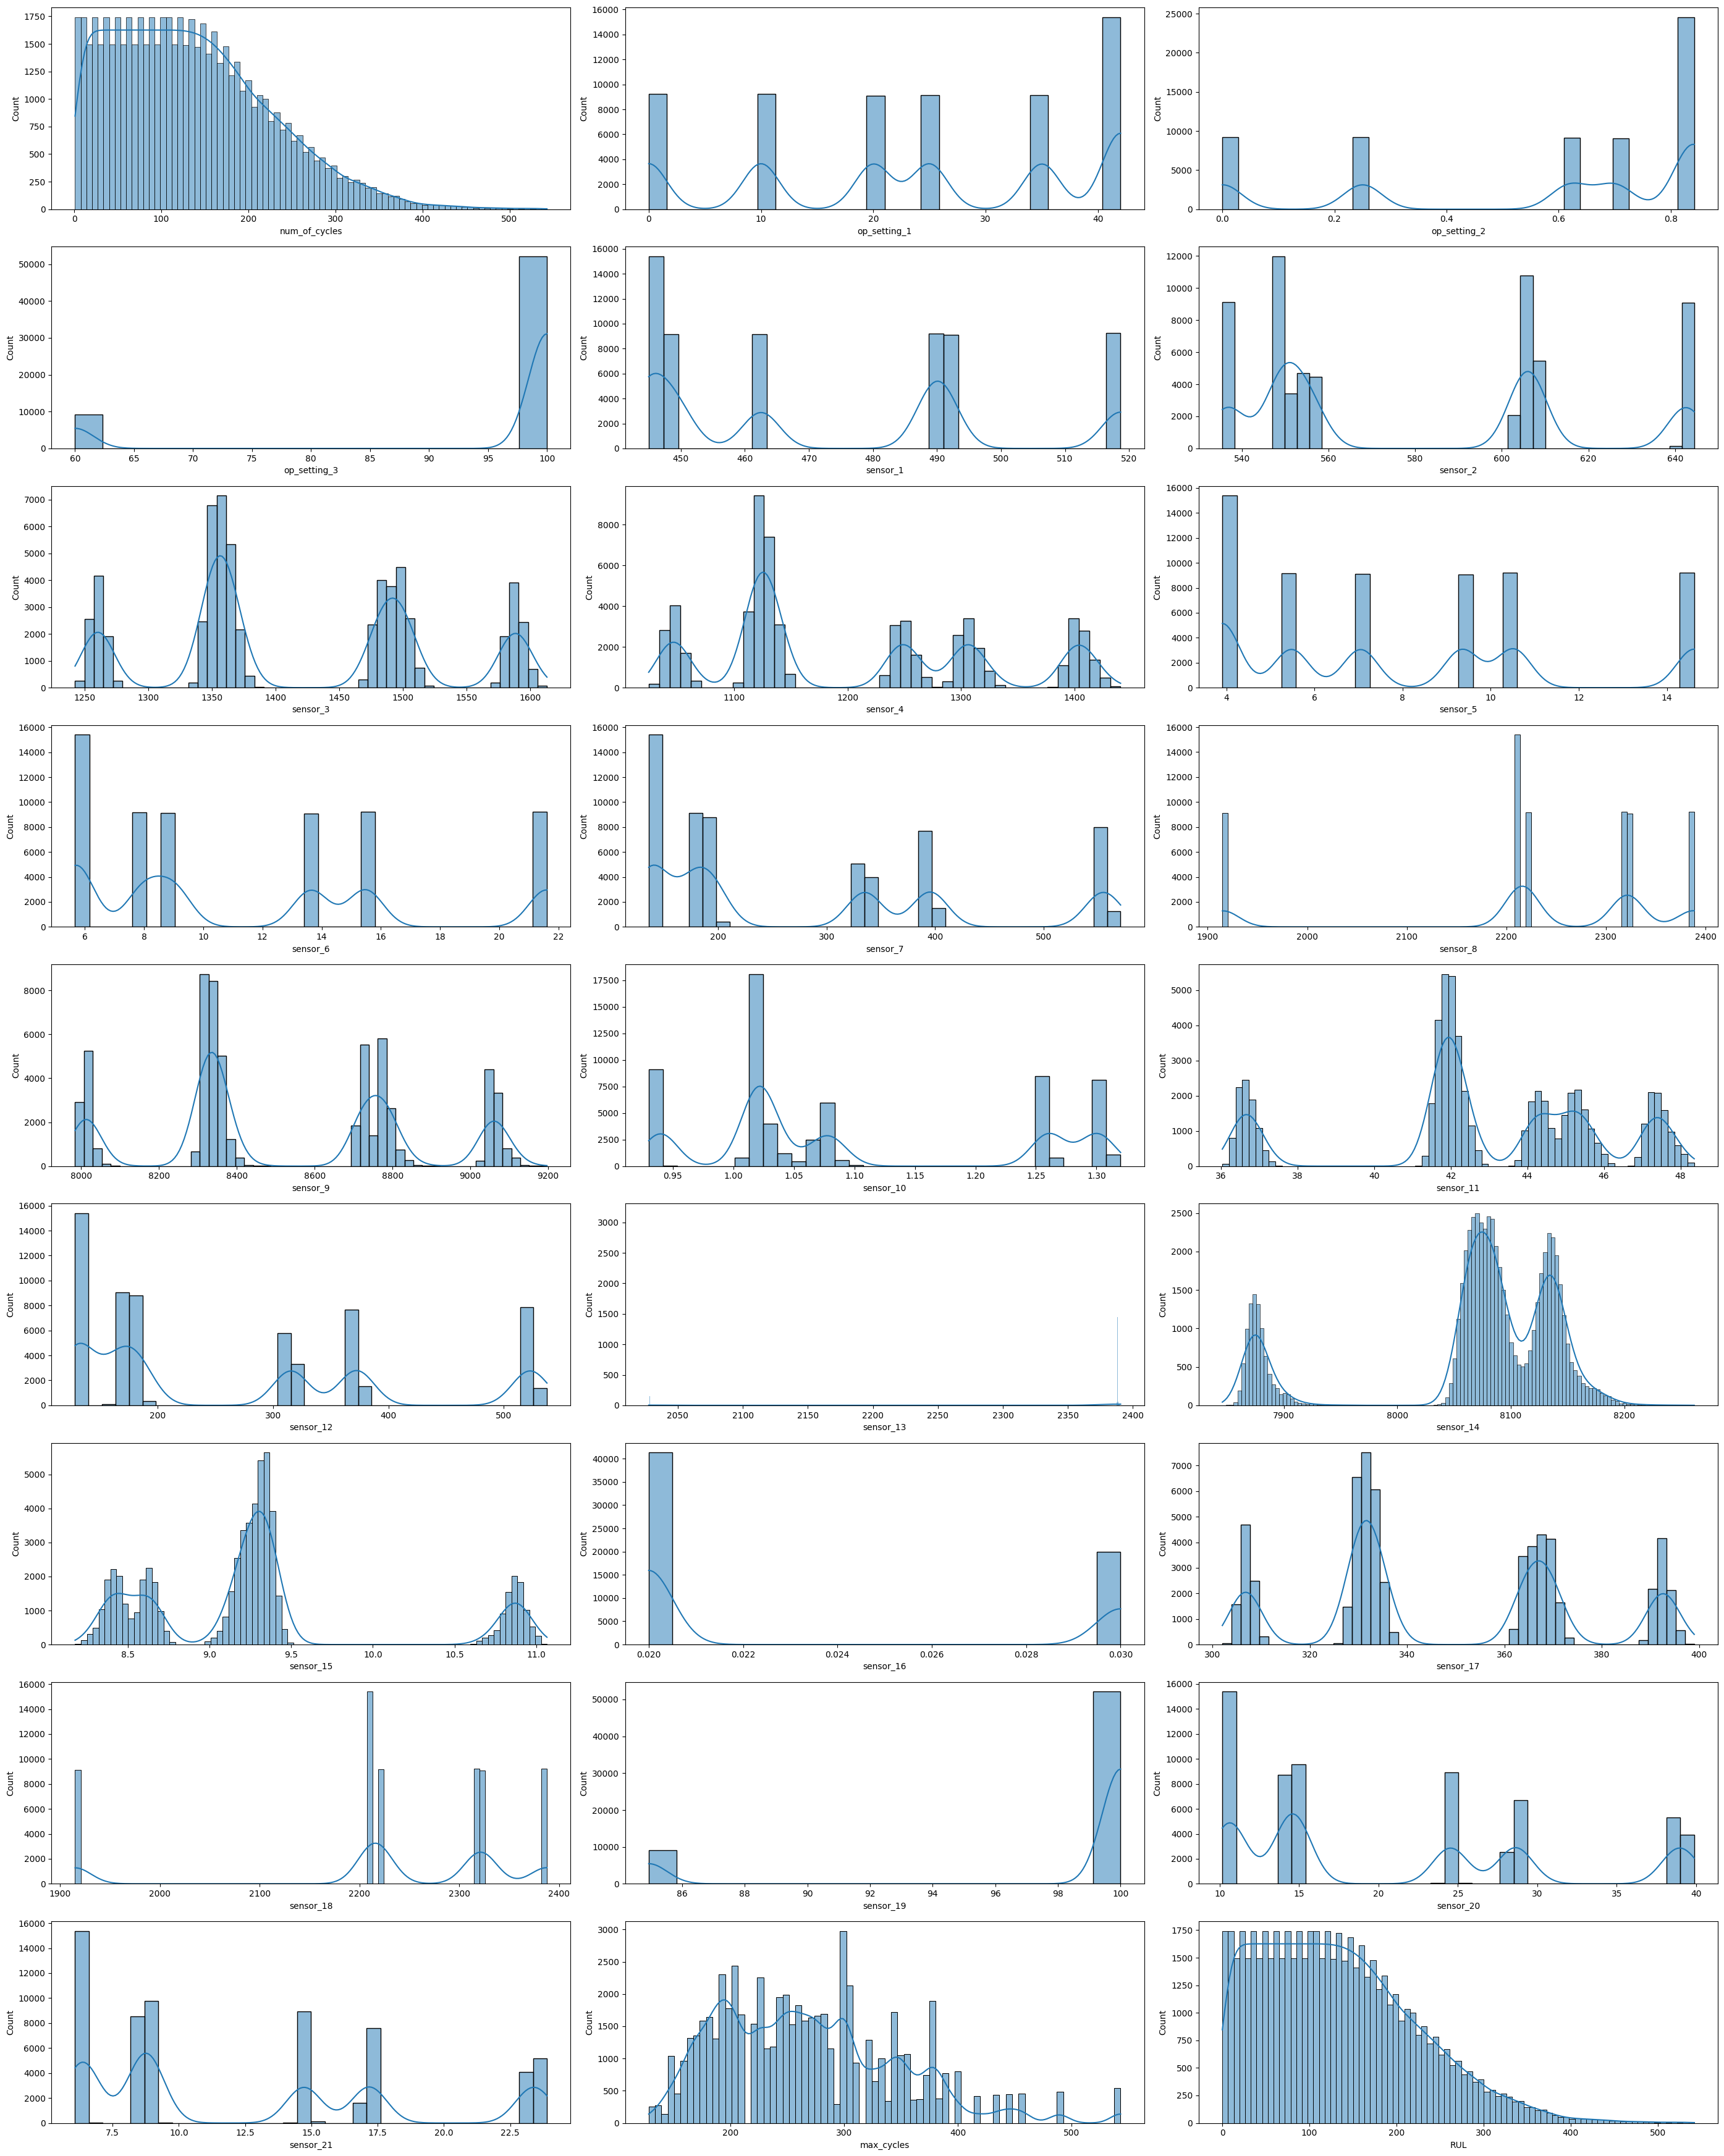

In [101]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(28,35))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(9, 3, i)
    sns.histplot(df[col], kde=True)
    plt.tight_layout()

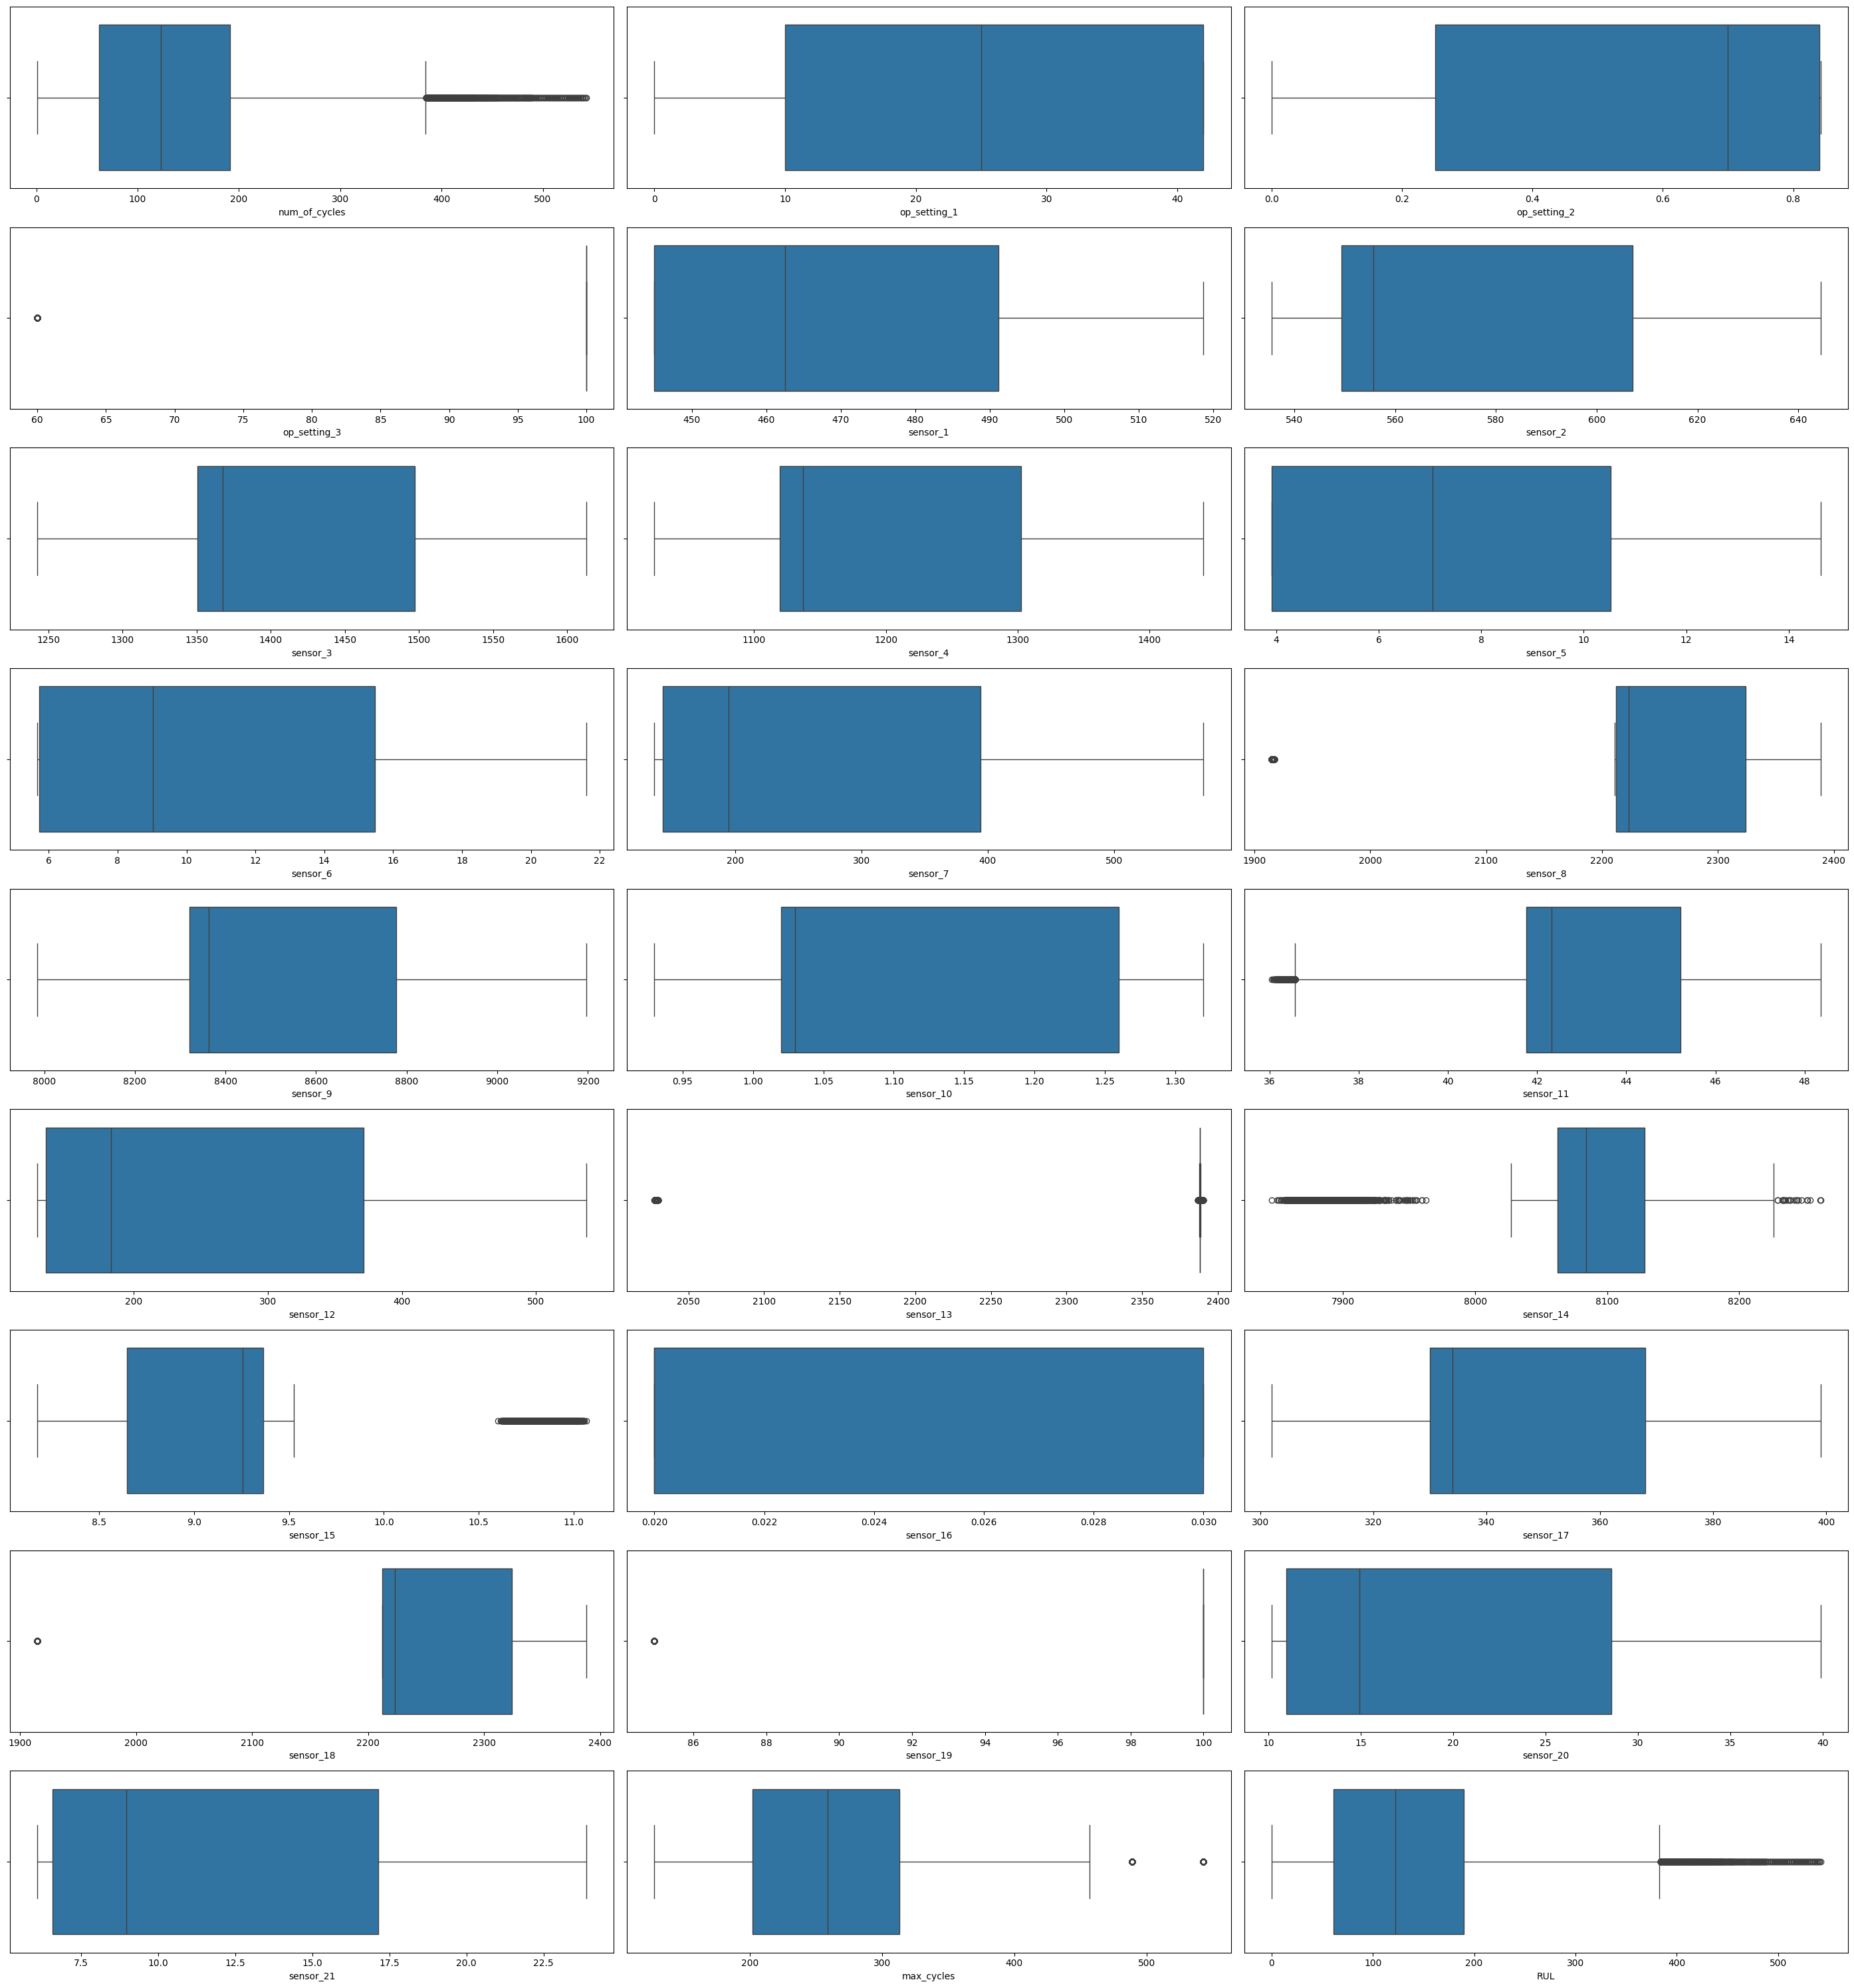

In [102]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(28,30))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(9, 3, i)
    sns.boxplot(x=df[col])
    plt.tight_layout()

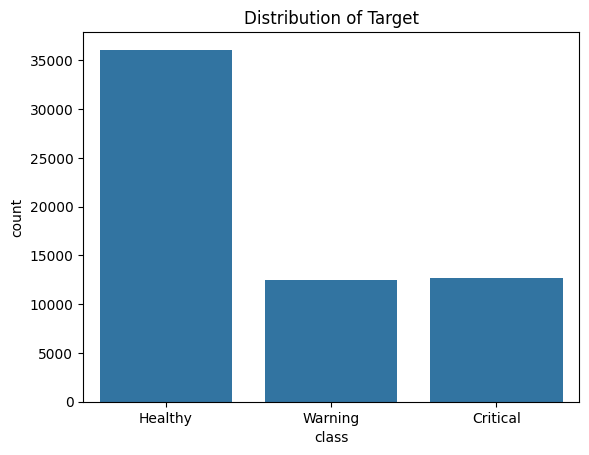

In [103]:
sns.countplot(x=df['class'])
plt.title("Distribution of Target")
plt.show()

### 2-Bivariate Analysis

In [104]:
numerical_df= df.drop("class",axis=1)
numerical_df.corr()

,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
num_of_cycles,1.000000,0.000330,0.001054,-0.001804,-0.000714,0.002485,0.023150,0.029288,-0.000516,-0.001317,...,0.097876,-0.027759,0.044349,0.022894,-0.001806,-0.001804,0.002438,0.002450,0.441263,-0.610602
op_setting_1,0.000330,1.000000,0.943796,-0.028433,-0.964753,-0.868389,-0.787846,-0.839987,-0.987382,-0.976518,...,-0.263965,0.460804,-0.840823,-0.790694,-0.444339,-0.028433,-0.962042,-0.962051,-0.002370,-0.002422
op_setting_2,0.001054,0.943796,1.000000,-0.066263,-0.886121,-0.811611,-0.761370,-0.837053,-0.933693,-0.929547,...,-0.356088,0.520312,-0.902159,-0.764489,-0.440553,-0.066263,-0.922003,-0.921999,-0.001422,-0.002309
op_setting_3,-0.001804,-0.028433,-0.066263,1.000000,0.163844,0.478668,0.620190,0.544490,0.113480,0.197803,...,0.928068,-0.881198,0.290758,0.616480,0.902832,1.000000,0.276249,0.276157,0.000550,0.002289
sensor_1,-0.000714,-0.964753,-0.886121,0.163844,1.000000,0.944438,0.870605,0.897421,0.986560,0.986539,...,0.353454,-0.542379,0.789446,0.872955,0.572081,0.163844,0.977777,0.977791,0.001373,0.001925
sensor_2,0.002485,-0.868389,-0.811611,0.478668,0.944438,1.000000,0.981750,0.980722,0.916509,0.944587,...,0.624373,-0.776159,0.800318,0.982621,0.809594,0.478668,0.962824,0.962806,-0.002188,-0.004416
sensor_3,0.023150,-0.787846,-0.761370,0.620190,0.870605,0.981750,1.000000,0.989744,0.842816,0.884586,...,0.755188,-0.875044,0.801511,0.998693,0.895023,0.620190,0.917055,0.917019,-0.011049,-0.032902
sensor_4,0.029288,-0.839987,-0.837053,0.544490,0.897421,0.980722,0.989744,1.000000,0.883579,0.919064,...,0.719329,-0.846003,0.858553,0.990407,0.843618,0.544490,0.945999,0.945965,-0.018775,-0.045858
sensor_5,-0.000516,-0.987382,-0.933693,0.113480,0.986560,0.916509,0.842816,0.883579,1.000000,0.996316,...,0.331140,-0.525068,0.824765,0.845583,0.524099,0.113480,0.985677,0.985695,0.001361,0.001717
sensor_6,-0.001317,-0.976518,-0.929547,0.197803,0.986539,0.944587,0.884586,0.919064,0.996316,1.000000,...,0.408119,-0.594841,0.841051,0.887014,0.594173,0.197803,0.996289,0.996299,0.000078,0.001386


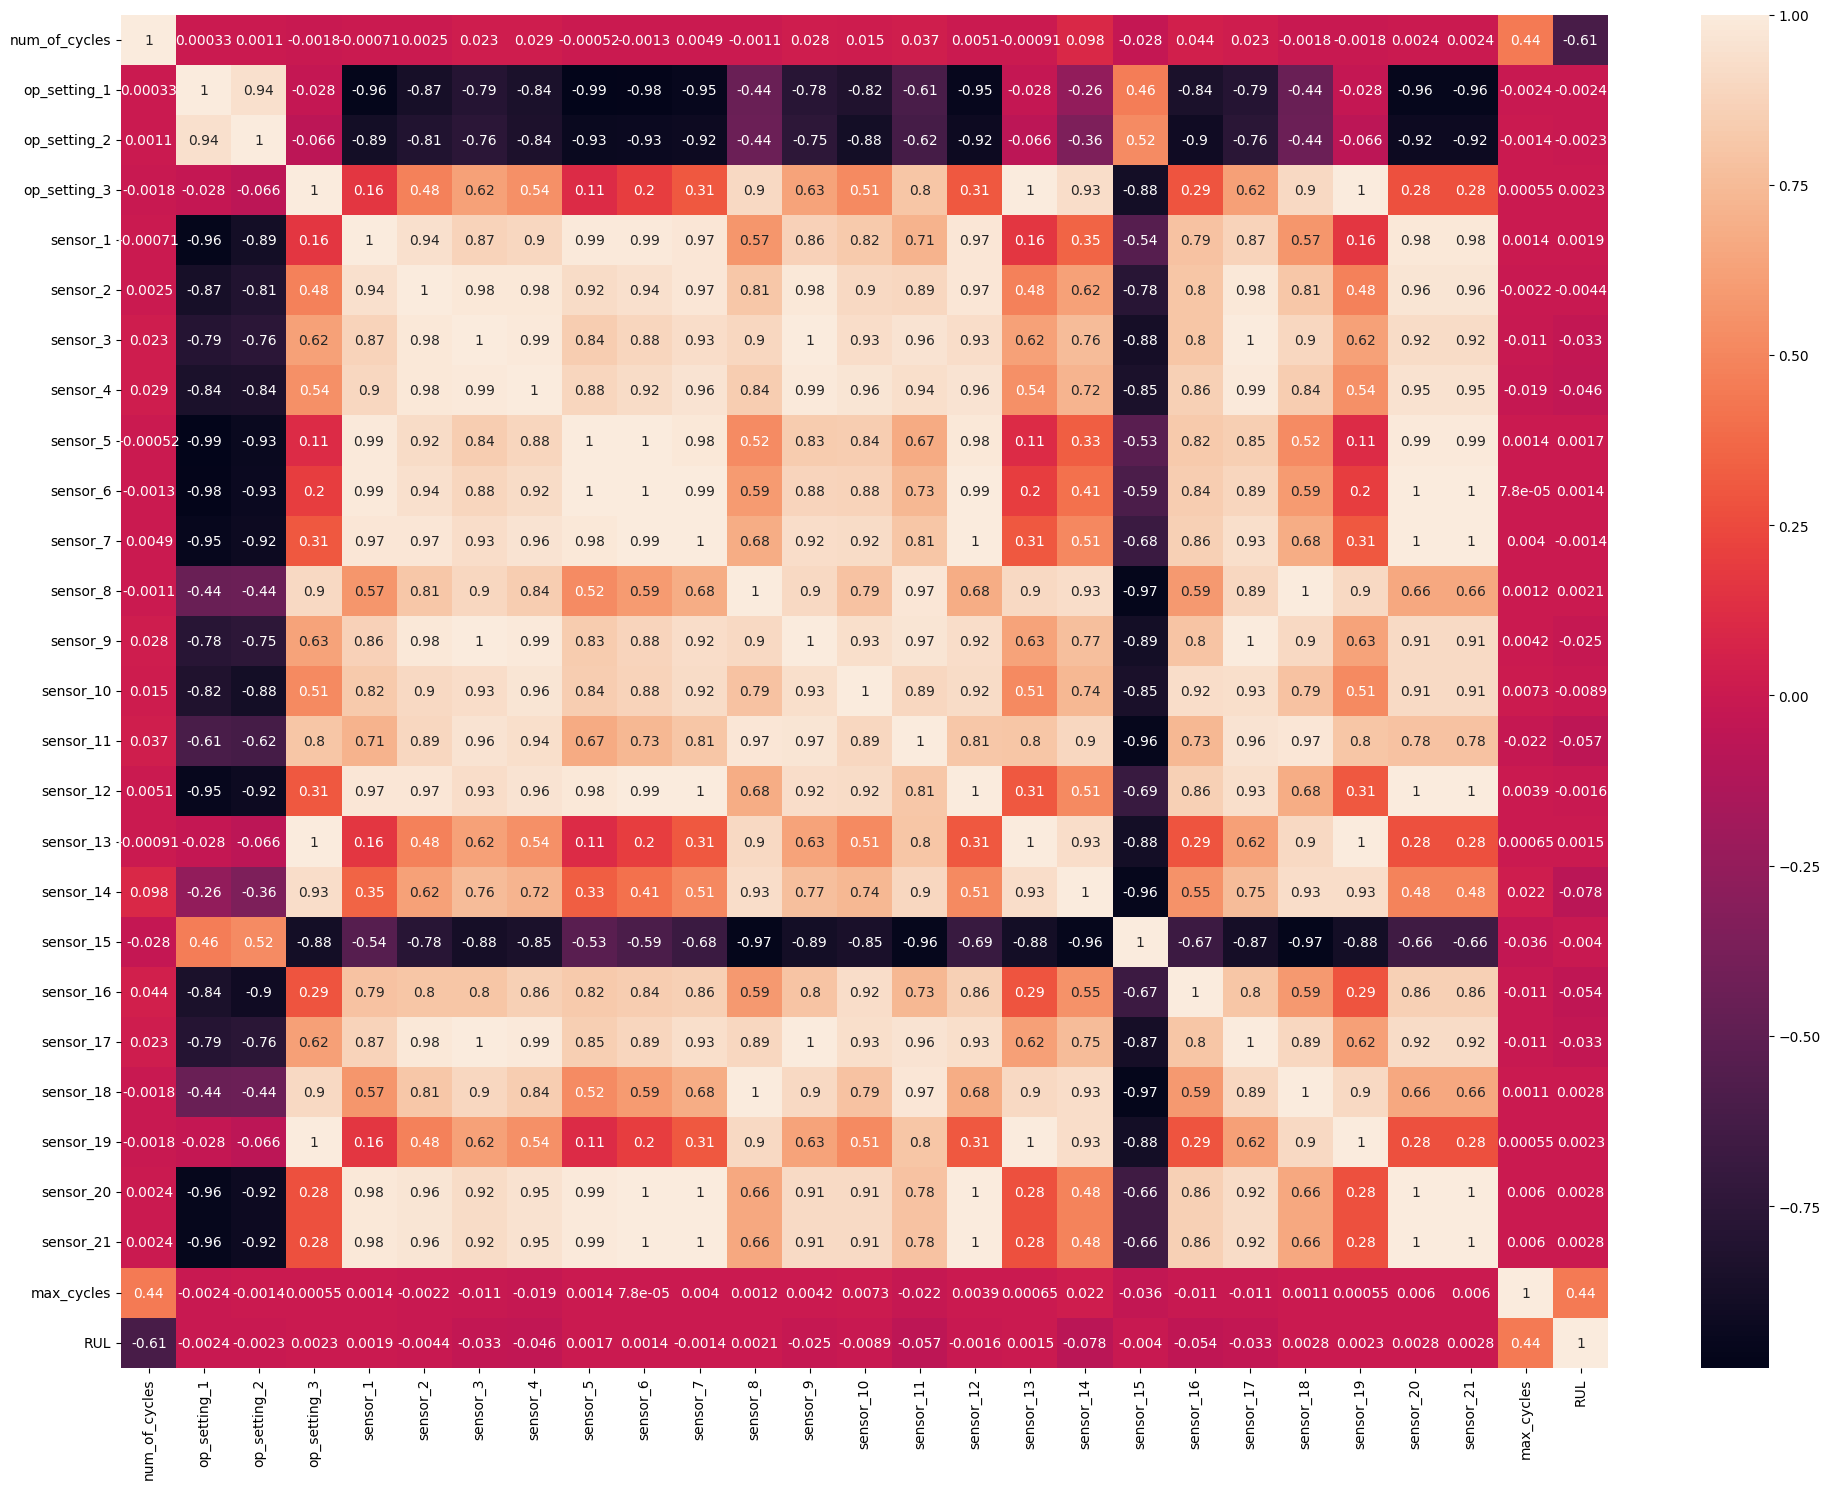

In [105]:
plt.figure(figsize=(20, 15))
sns.heatmap(numerical_df.corr(), annot=True)
plt.tight_layout()
plt.show()

In [106]:
numerical_df.corr()['RUL'].sort_values()

,RUL
num_of_cycles,-0.610602
sensor_14,-0.078132
sensor_11,-0.056629
sensor_16,-0.053783
sensor_4,-0.045858
sensor_17,-0.032919
sensor_3,-0.032902
sensor_9,-0.024707
sensor_10,-0.008901
sensor_2,-0.004416


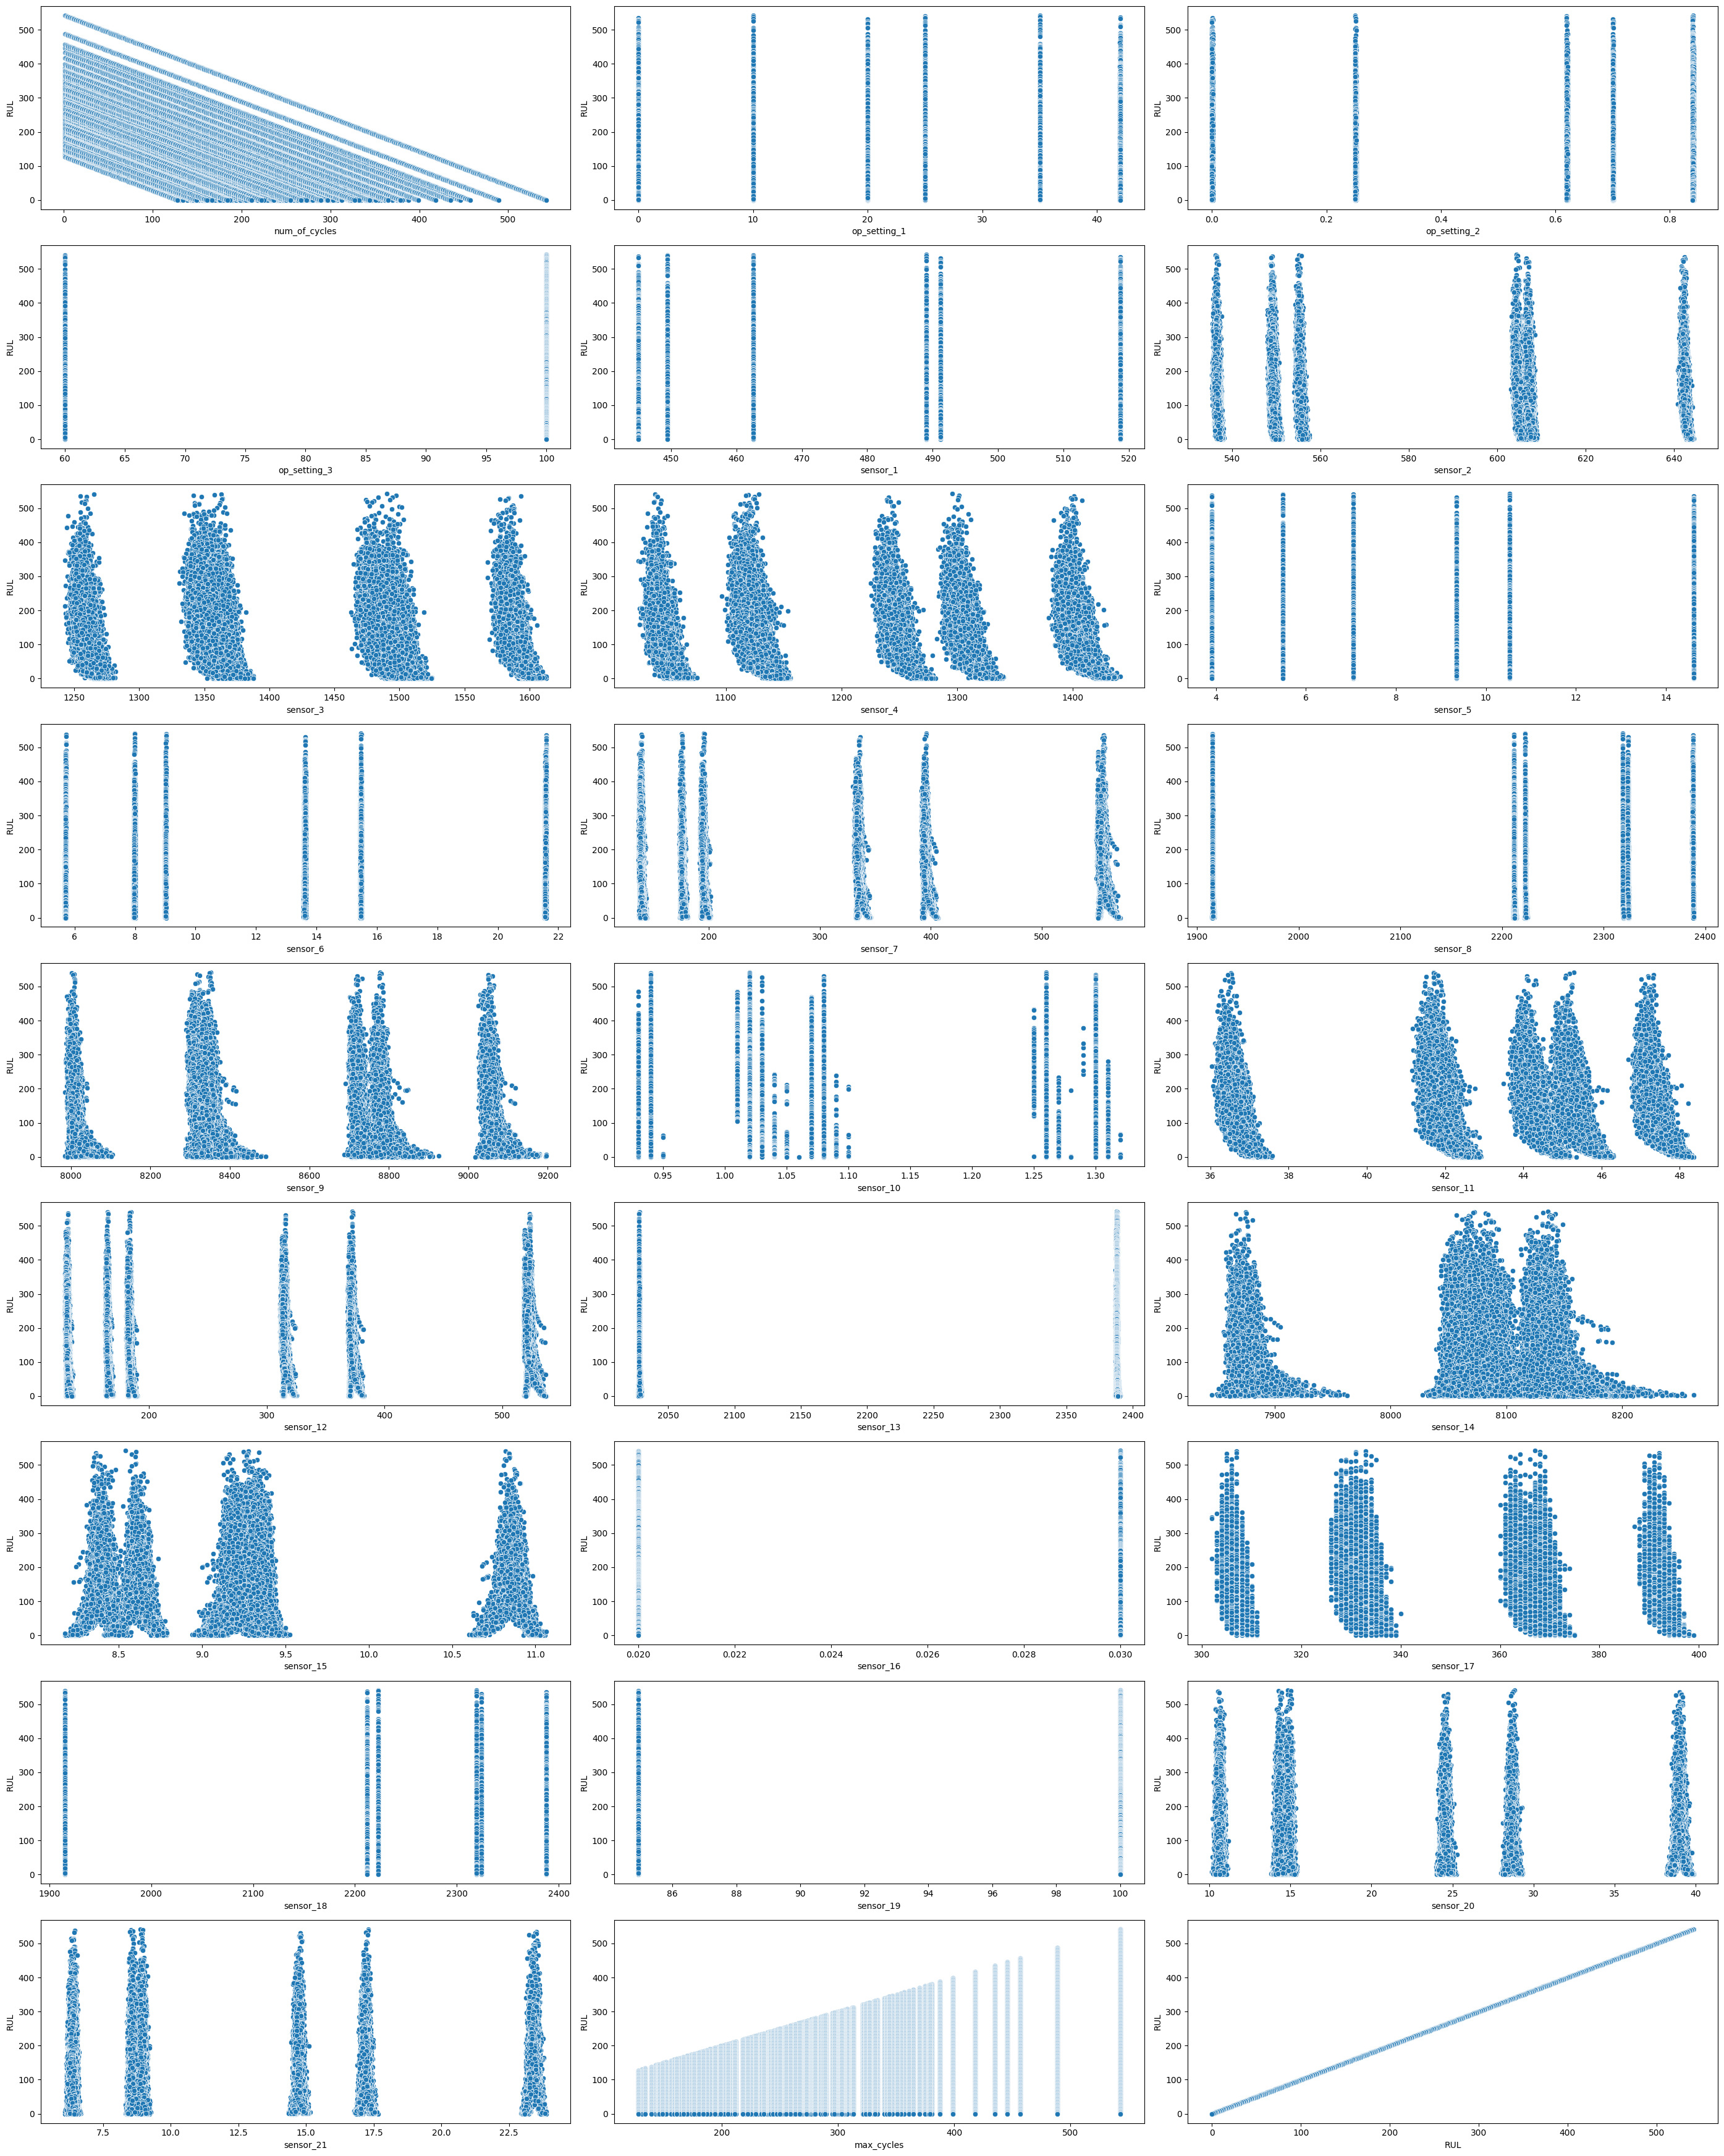

In [107]:
plt.figure(figsize=(28,35))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(9, 3, i)
    sns.scatterplot(data=df,x=col,y="RUL")
    plt.tight_layout()

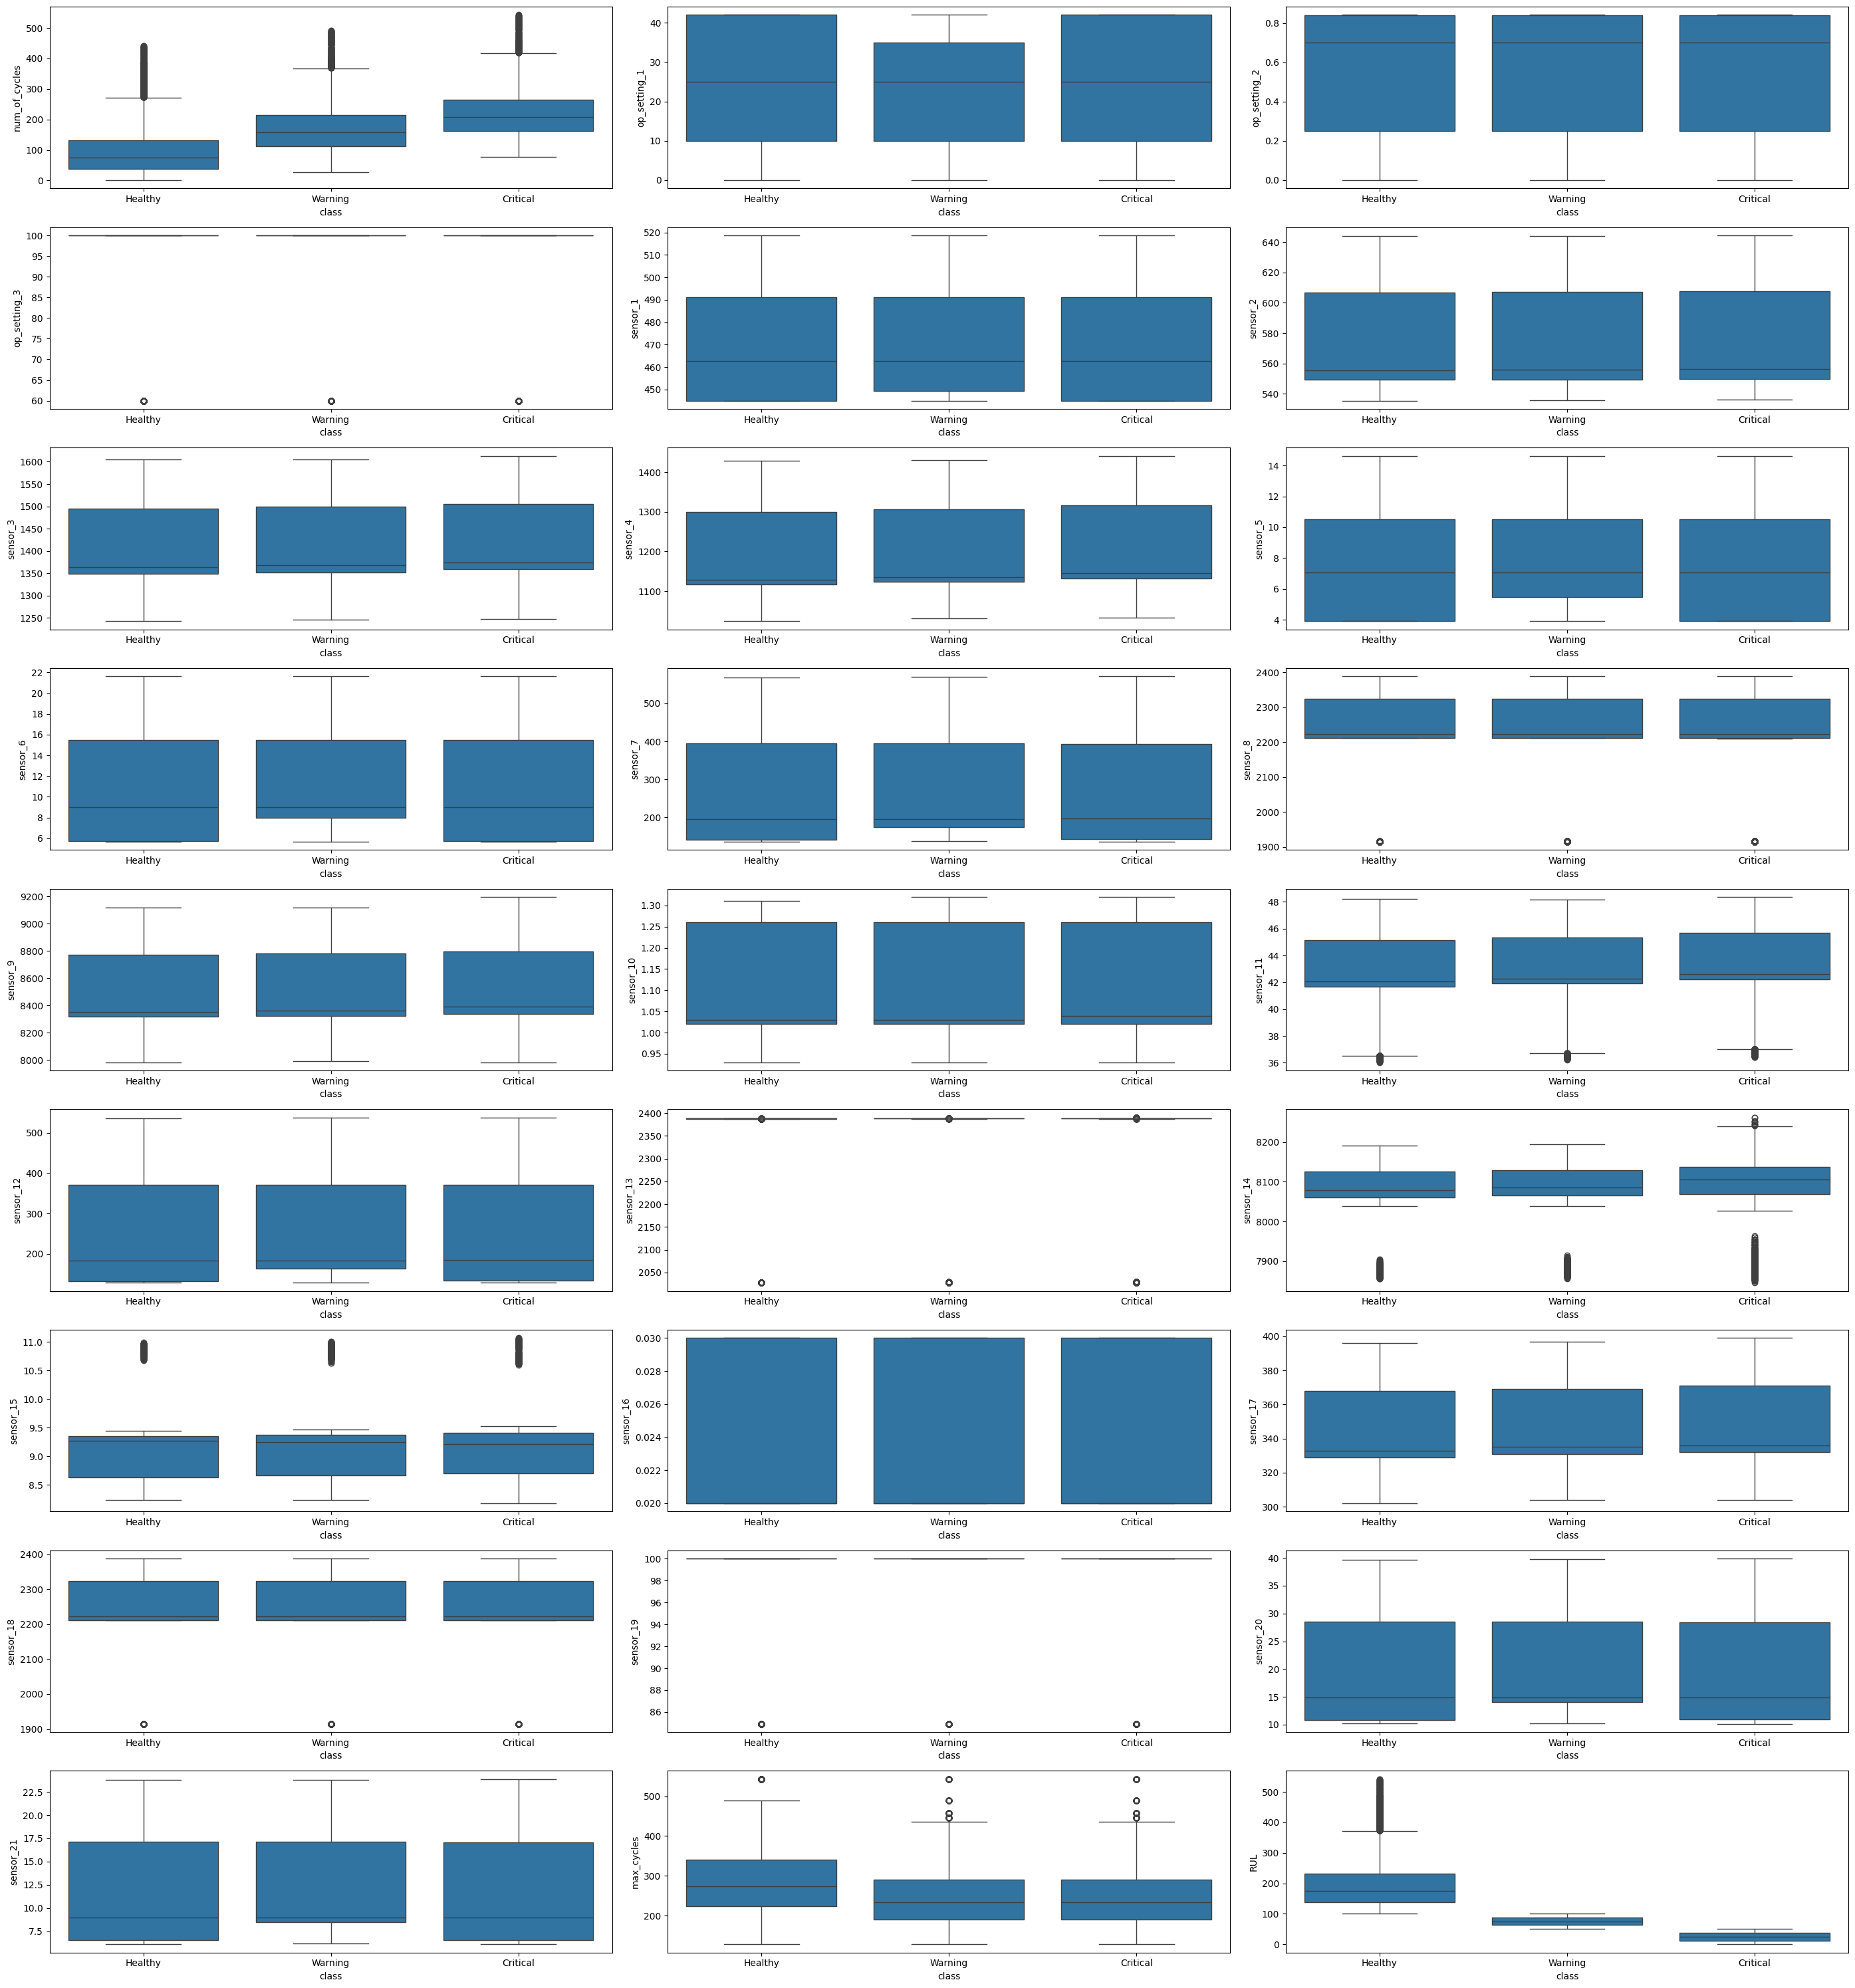

In [108]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(28,30))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(9, 3, i)
    sns.boxplot(data=df,x="class",y=col)
    plt.tight_layout()

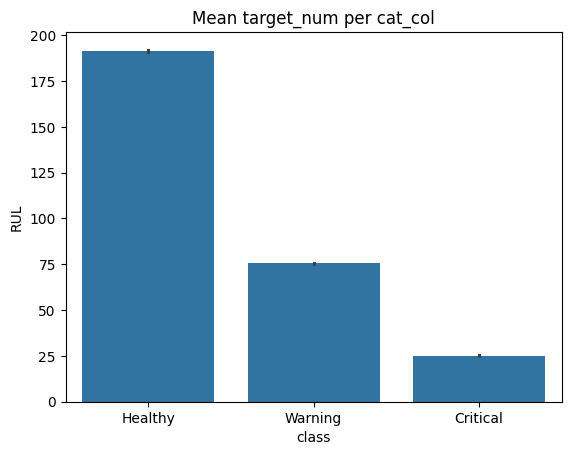

In [109]:
sns.barplot(data=df, x='class', y='RUL', estimator='mean')
plt.title('Mean target_num per cat_col')
plt.show()

In [110]:
df.groupby('class').agg(["min","max","mean","median","std"])

num_of_cycles                                    op_setting_1  \
                   min  max        mean median        std          min   
class                                                                    
Critical            78  543  220.979920  209.0  74.436721          0.0   
Healthy              1  442   91.352669   76.0  69.861728          0.0   
Warning             28  492  170.479920  159.0  74.380218          0.0   

                                                 ... max_cycles       \
             max       mean   median        std  ...        min  max   
class                                            ...                   
Critical  42.008  24.063101  25.0014  14.814397  ...        128  543   
Healthy   42.008  24.028543  25.0016  14.765549  ...        128  543   
Warning   42.008  23.850561  25.0011  14.790231  ...        128  543   

                                        RUL                                     
                mean median        std  min  max        mean median        std  
class                                                                           
Critical  245.979920  234.0  72.966717    0   50   25.000000   25.0  14.720181  
Healthy   282.699271  274.0  79.929100  101  542  191.346602  176.0  69.860065  
Warning   245.979920  234.0  72.966774   51  100   75.500000   75.5  14.431449  

[3 rows x 135 columns]

### 3-Multivariate Analysis

In [111]:
'''from statsmodels.stats.outliers_influence import variance_inflation_factor
numerical_cols=numerical_cols = df.select_dtypes("number").columns.drop("RUL")
X = df[numerical_cols]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)'''

'from statsmodels.stats.outliers_influence import variance_inflation_factor\nnumerical_cols=numerical_cols = df.select_dtypes("number").columns.drop("RUL")\nX = df[numerical_cols]\n\nvif_data = pd.DataFrame()\nvif_data["feature"] = X.columns\nvif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]\n\nprint(vif_data)'

In [112]:
# Identify numeric columns
num_cols = df.select_dtypes(include=np.number).columns
print("Numeric columns:")
print(num_cols)



Numeric columns:
Index(['num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycles', 'RUL'],
      dtype='object')


In [113]:
# Z-score method
z_scores = np.abs(stats.zscore(df[num_cols]))
outliers_z = (z_scores > 3).sum(axis=0)
print("Outliers detected by Z-score method per column:")
print(outliers_z)


Outliers detected by Z-score method per column:
[370   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0 543 370]


In [114]:


# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
print("Outliers detected by IQR method per column:")
print(outliers_iqr)


Outliers detected by IQR method per column:
num_of_cycles      522
op_setting_1         0
op_setting_2         0
op_setting_3      9139
sensor_1             0
sensor_2             0
sensor_3             0
sensor_4             0
sensor_5             0
sensor_6             0
sensor_7             0
sensor_8          9139
sensor_9             0
sensor_10            0
sensor_11         3102
sensor_12            0
sensor_13        11546
sensor_14         9162
sensor_15         9139
sensor_16            0
sensor_17            0
sensor_18         9139
sensor_19         9139
sensor_20            0
sensor_21            0
max_cycles        1032
RUL                522
dtype: int64


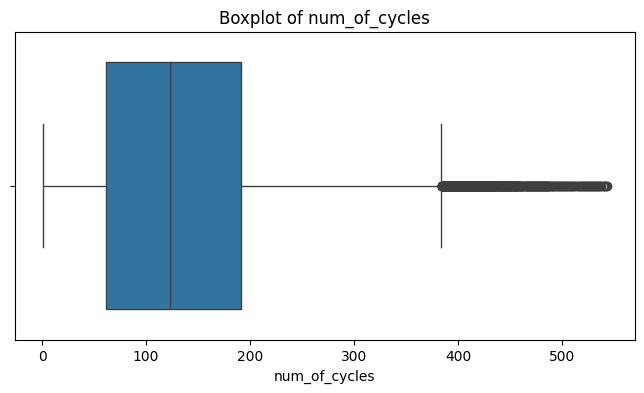

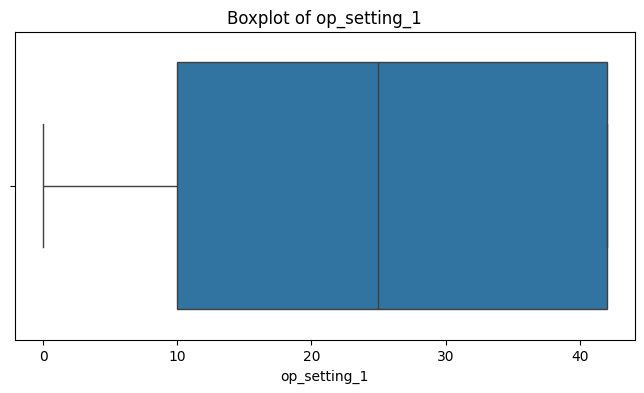

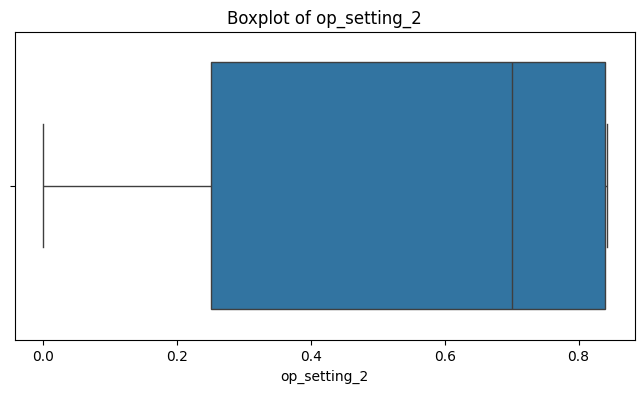

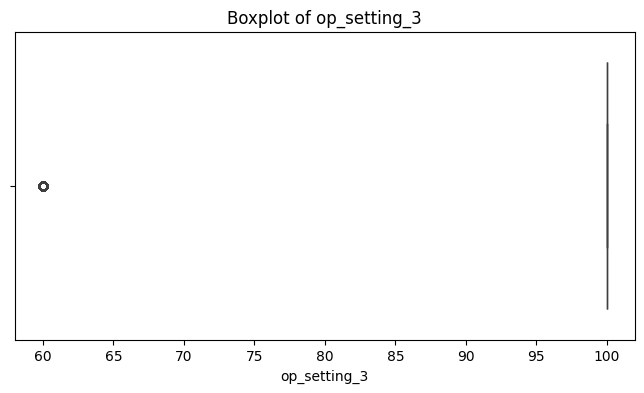

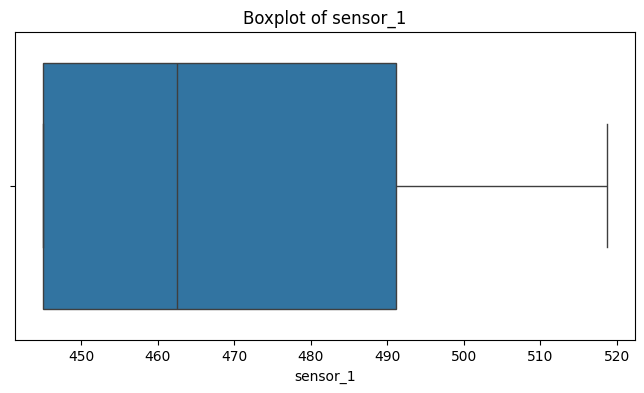

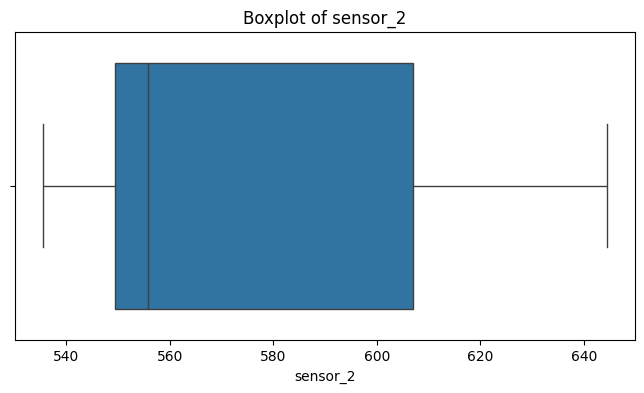

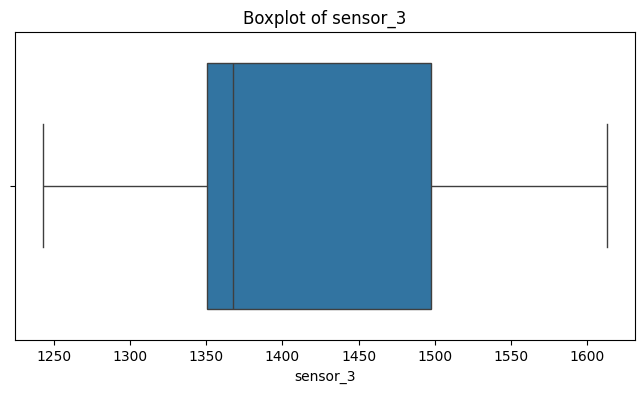

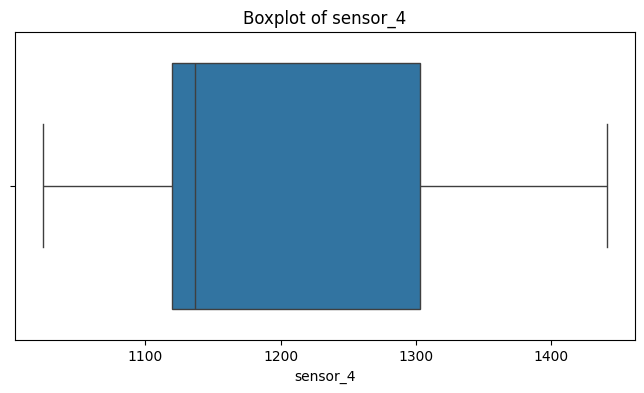

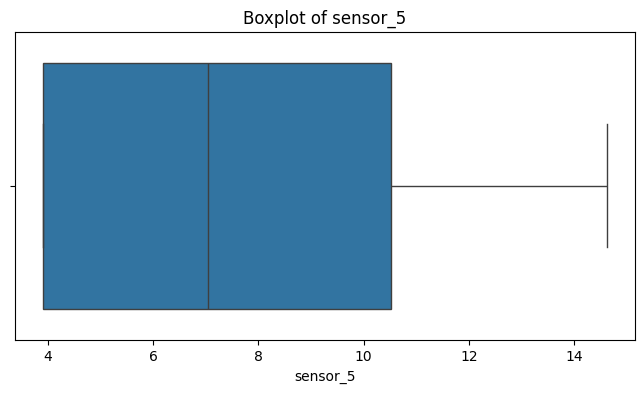

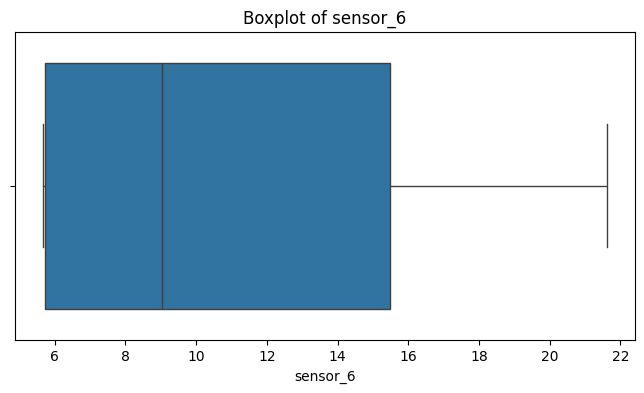

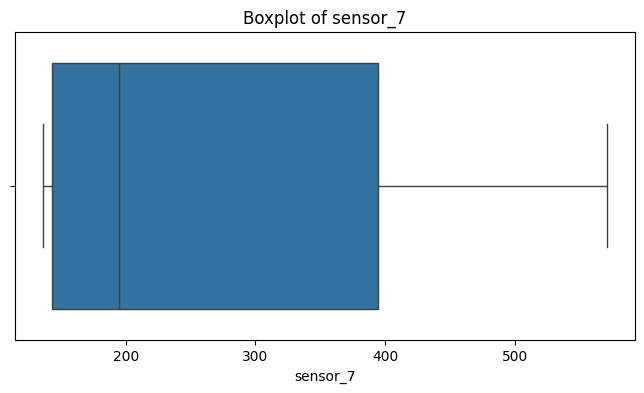

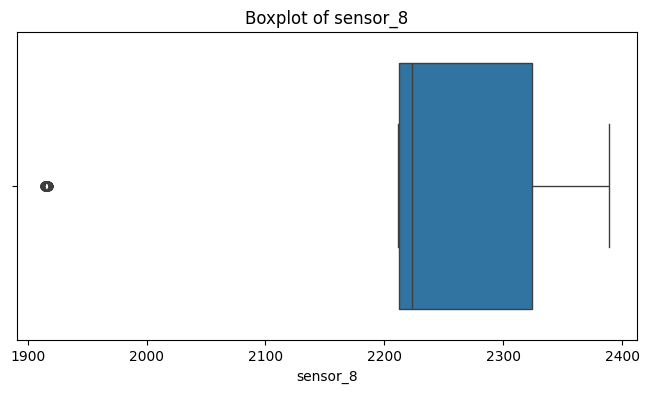

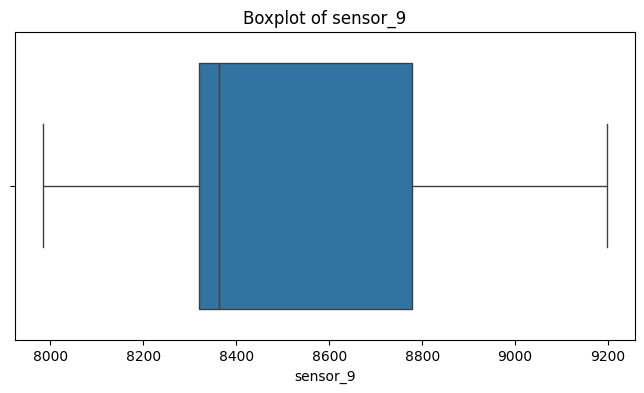

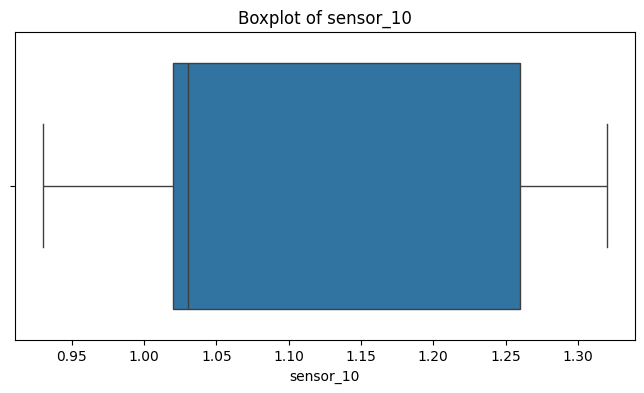

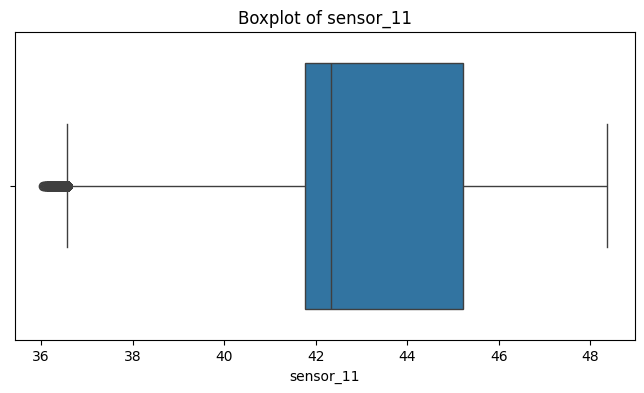

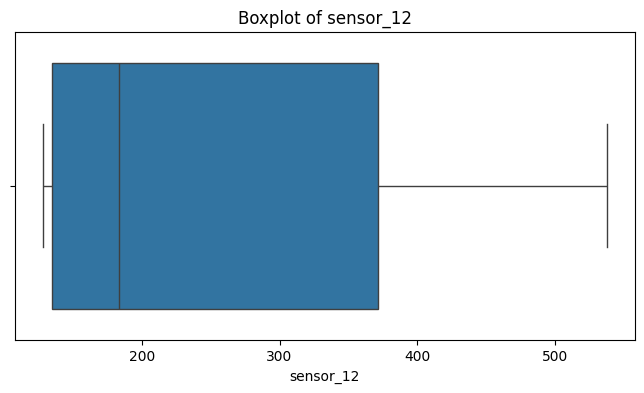

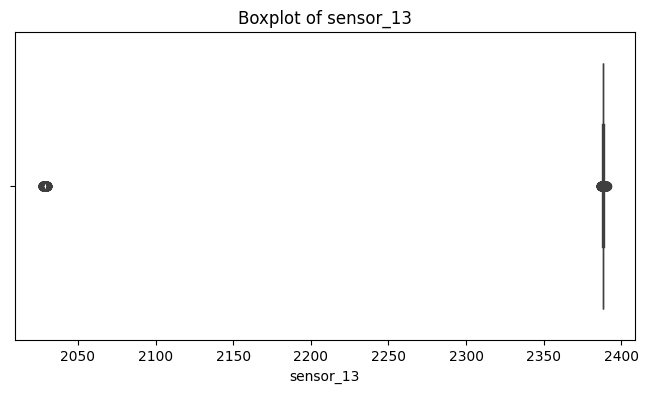

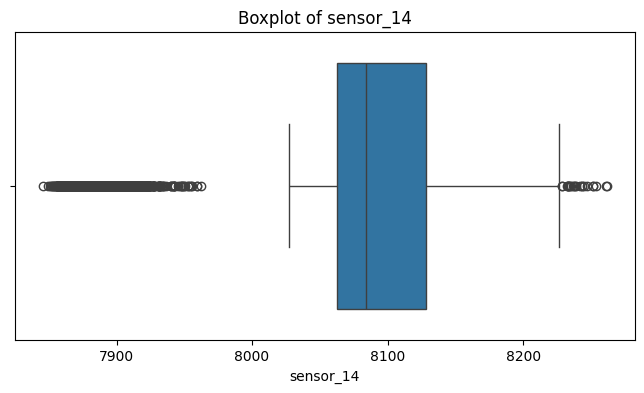

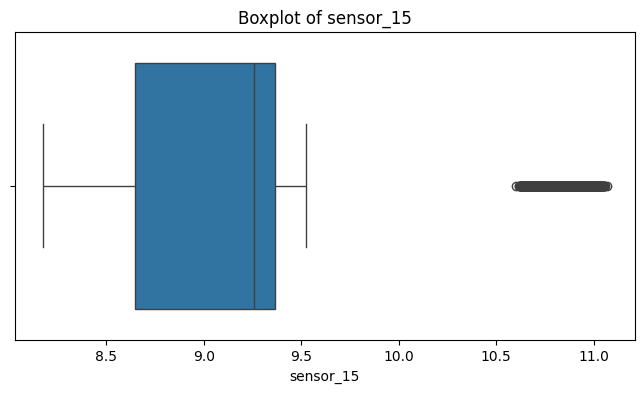

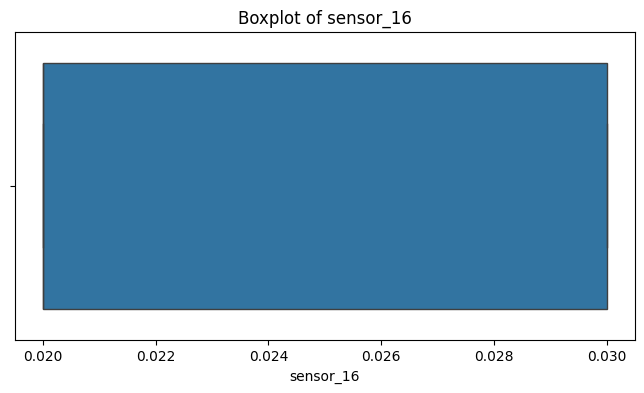

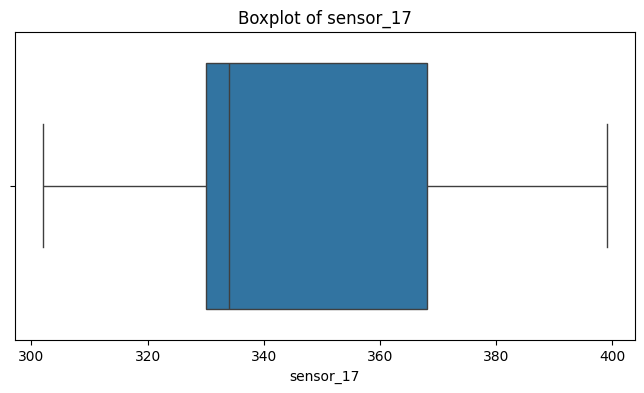

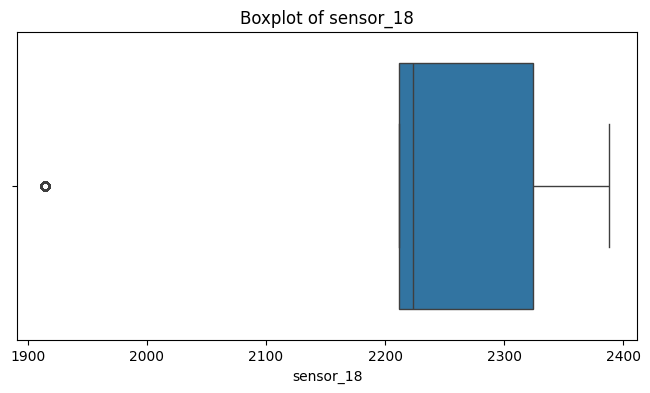

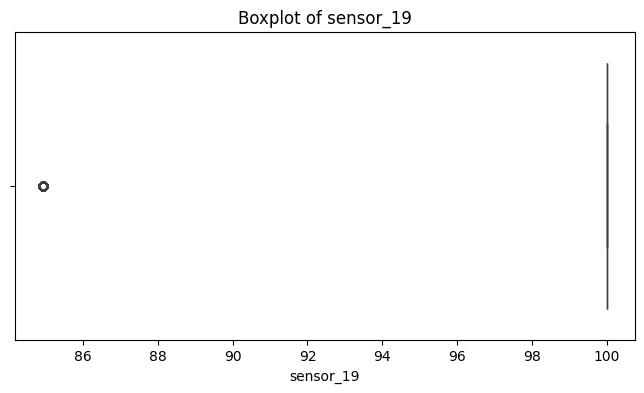

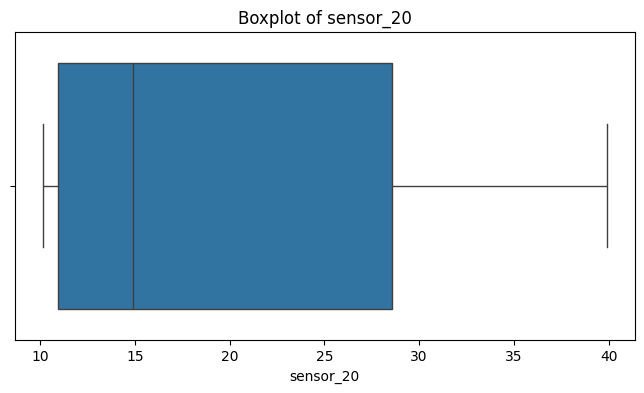

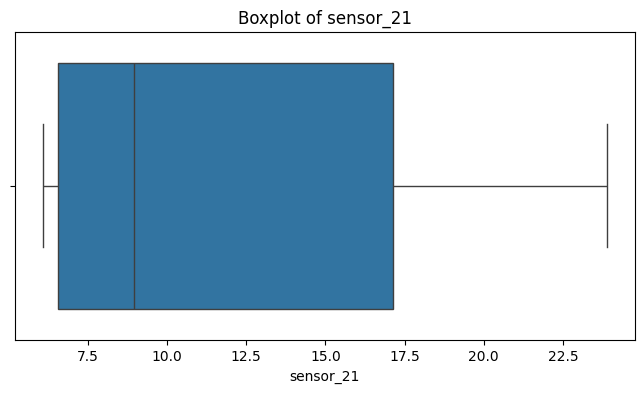

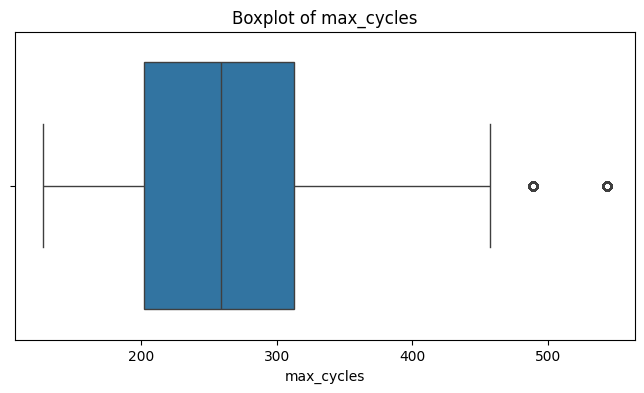

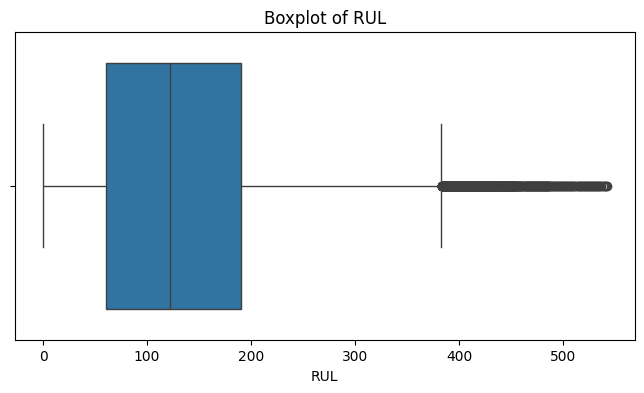

In [115]:

import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [116]:
# Check for negative values
for col in num_cols:
    if (df[col] < 0).any():
        print(f"Negative values found in column {col}")


In [117]:
# Rare categories for numeric columns with few unique values
for col in num_cols:
    if df[col].nunique() < 20:
        value_counts = df[col].value_counts(normalize=True)
        rare = value_counts[value_counts < 0.01]
        if not rare.empty:
            print(f"Rare categories in {col}:")
            print(rare)



In [118]:
#!pip install ydata-profiling

In [119]:
# Optional: Automated EDA report using ydata_profiling
'''
import ydata_profiling
profile = ydata_profiling.ProfileReport(df)
profile.to_widgets()
profile.to_file("eda_report.html")'''




'\nimport ydata_profiling\nprofile = ydata_profiling.ProfileReport(df)\nprofile.to_widgets()\nprofile.to_file("eda_report.html")'

In [120]:


# Correlation of numeric features with RUL
correlations = df[num_cols].corr()["RUL"].sort_values(ascending=False)
print("Correlation of numeric features with RUL:")
print(correlations)


Correlation of numeric features with RUL:
RUL              1.000000
max_cycles       0.441231
sensor_20        0.002847
sensor_21        0.002826
sensor_18        0.002769
op_setting_3     0.002289
sensor_19        0.002289
sensor_8         0.002090
sensor_1         0.001925
sensor_5         0.001717
sensor_13        0.001487
sensor_6         0.001386
sensor_7        -0.001395
sensor_12       -0.001606
op_setting_2    -0.002309
op_setting_1    -0.002422
sensor_15       -0.003959
sensor_2        -0.004416
sensor_10       -0.008901
sensor_9        -0.024707
sensor_3        -0.032902
sensor_17       -0.032919
sensor_4        -0.045858
sensor_16       -0.053783
sensor_11       -0.056629
sensor_14       -0.078132
num_of_cycles   -0.610602
Name: RUL, dtype: float64


#  4-Data Preprocessing

### 1-Feature Selection

In [121]:
    # Identify columns to drop
no_variance = [col for col in df.columns if df[col].nunique() == 1]
print("\n" + "="*50)
print("FEATURE SELECTION")
print("="*50)
print("Columns with no variance (to drop):", no_variance)


FEATURE SELECTION
Columns with no variance (to drop): []


In [122]:
# Columns to drop
columns_to_drop = ['id', 'max_cycles'] + no_variance
df = df.drop(columns=columns_to_drop, errors='ignore')

print("\nFeatures after initial selection:")
print(df.columns.tolist())


Features after initial selection:
['num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'RUL', 'class']


###  2- Outlier Detection

In [123]:
print("\n" + "="*50)
print(" OUTLIER DETECTION")
print("="*50)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'RUL' in numerical_cols:
    numerical_cols.remove('RUL')  # Don't remove outliers from target
    outliers_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_percentage = (outliers / len(df)) * 100

    if outliers > 0:
        outliers_summary[col] = {
            'outliers': outliers,
            'percentage': outliers_percentage,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

print(f"Columns with outliers: {len(outliers_summary)} out of {len(numerical_cols)}")
if outliers_summary:
    outliers_df = pd.DataFrame(outliers_summary).T
    print("\nOutliers summary:")
    print(outliers_df[['outliers', 'percentage']].sort_values('percentage', ascending=False).head(10))


 OUTLIER DETECTION
Columns with outliers: 9 out of 25

Outliers summary:
               outliers  percentage
sensor_13       11546.0   18.851228
sensor_14        9162.0   14.958856
sensor_18        9139.0   14.921304
sensor_8         9139.0   14.921304
op_setting_3     9139.0   14.921304
sensor_19        9139.0   14.921304
sensor_15        9139.0   14.921304
sensor_11        3102.0    5.064655
num_of_cycles     522.0    0.852273


### 3- Handle Outliers

In [124]:
print("\n" + "="*50)
print("OUTLIER TREATMENT")
print("="*50)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'RUL' in numerical_cols:
    numerical_cols.remove('RUL')

total_outliers = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before capping
    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    if outliers_before > 0:
        print(f"{col}: {outliers_before} outliers ({outliers_before/len(df)*100:.2f}%)")
        total_outliers += outliers_before

    # Apply capping
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print(f"\nTotal outliers handled: {total_outliers}")
print(f"Total rows in dataset: {len(df)}")
print("="*50)


OUTLIER TREATMENT
num_of_cycles: 522 outliers (0.85%)
op_setting_3: 9139 outliers (14.92%)
sensor_8: 9139 outliers (14.92%)
sensor_11: 3102 outliers (5.06%)
sensor_13: 11546 outliers (18.85%)
sensor_14: 9162 outliers (14.96%)
sensor_15: 9139 outliers (14.92%)
sensor_18: 9139 outliers (14.92%)
sensor_19: 9139 outliers (14.92%)

Total outliers handled: 70027
Total rows in dataset: 61248


### 4-Handle ImBalanced Data

In [125]:
print("\n" + "="*50)
print(" HANDLE IMBALANCED DATA")
print("="*50)

from imblearn.over_sampling import SMOTE # type: ignore
from collections import Counter

X = df.drop(['class', 'RUL'], axis=1)
y = df['class']

print("Before balancing:")
print(Counter(y))

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE balancing:")
print(Counter(y_balanced))

df_balanced = pd.concat([pd.DataFrame(X_balanced, columns=X.columns),
                         pd.DataFrame(y_balanced, columns=['class'])], axis=1)
df = df_balanced.copy()

print(f"\nOriginal dataset size: {len(X)}")
print(f"Balanced dataset size: {len(X_balanced)}")
print("="*50)


 HANDLE IMBALANCED DATA
Before balancing:
Counter({'Healthy': 36099, 'Critical': 12699, 'Warning': 12450})

After SMOTE balancing:
Counter({'Healthy': 36099, 'Warning': 36099, 'Critical': 36099})

Original dataset size: 61248
Balanced dataset size: 108297


In [126]:
np.random.seed(42)
rul_values = []
for cls in df_balanced['class']:
    if cls == 'Critical':
        rul_values.append(np.random.randint(0, 50))
    elif cls == 'Warning':
        rul_values.append(np.random.randint(50, 100))
    else:
        rul_values.append(np.random.randint(100, 200))
df_balanced['RUL'] = rul_values

### 5-Encoding Categorical Variables

In [127]:
from sklearn.preprocessing import LabelEncoder

print("\n" + "="*50)
print(" ENCODING CATEGORICAL VARIABLES")
print("="*50)

label_encoder = LabelEncoder()
df['class_encoded'] = label_encoder.fit_transform(df['class'])
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Class mapping: {class_mapping}")

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'class']

print(f"Categorical columns to encode: {categorical_cols}")

if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"Encoded categorical columns: {categorical_cols}")

# Convert boolean columns to int (0/1) if needed
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)

print("Data after encoding:")
print(df.info())
print(f"\nData shape: {df.shape}")


 ENCODING CATEGORICAL VARIABLES
Class mapping: {'Critical': np.int64(0), 'Healthy': np.int64(1), 'Warning': np.int64(2)}
Categorical columns to encode: []
Data after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108297 entries, 0 to 108296
Data columns (total 27 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   num_of_cycles  108297 non-null  float64
 1   op_setting_1   108297 non-null  float64
 2   op_setting_2   108297 non-null  float64
 3   op_setting_3   108297 non-null  float64
 4   sensor_1       108297 non-null  float64
 5   sensor_2       108297 non-null  float64
 6   sensor_3       108297 non-null  float64
 7   sensor_4       108297 non-null  float64
 8   sensor_5       108297 non-null  float64
 9   sensor_6       108297 non-null  float64
 10  sensor_7       108297 non-null  float64
 11  sensor_8       108297 non-null  float64
 12  sensor_9       108297 non-null  float64
 13  sensor_10      108297 non-null  

### 6-Feature Scaling

In [128]:
print("\n" + "="*50)
print("FEATURE SCALING")
print("="*50)

# Define numerical columns again
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target columns from numerical columns
target_cols = ['class_encoded', 'RUL', 'class']
numerical_cols = [col for col in numerical_cols if col not in target_cols]

print(f"Numerical features to scale: {numerical_cols}")
print(f"Number of features: {len(numerical_cols)}")

# Separate features and target
X = df[numerical_cols].copy()
y_class = df['class_encoded']

# Check if RUL exists in the dataframe
if 'RUL' in df.columns:
    y_rul = df['RUL']
    print("RUL column found for regression task")
else:
    y_rul = None
    print("RUL column not found (skip regression task)")

# Handle missing values (if any)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

print("\nFirst 5 rows before scaling:")
print(X.head().round(4))

# Standardization (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows after scaling:")
print(X_scaled_df.head().round(4))

# Update the dataframe with scaled features
df_scaled = pd.concat([
    X_scaled_df,
    pd.DataFrame(y_class, columns=['class_encoded'])
], axis=1)

if y_rul is not None:
    df_scaled['RUL'] = y_rul.values

df = df_scaled.copy()
print(f"Final dataframe shape: {df.shape}")


FEATURE SCALING
Numerical features to scale: ['num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']
Number of features: 25
RUL column not found (skip regression task)

First 5 rows before scaling:
   num_of_cycles  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0            2.0       20.0020        0.7002         100.0    491.19   
1            3.0       42.0038        0.8409         100.0    445.00   
2            4.0       42.0000        0.8400         100.0    445.00   
3            5.0       25.0063        0.6207         100.0    462.54   
4            6.0       34.9996        0.8400         100.0    449.44   

   sensor_2  sensor_3  sensor_4  sensor_5  sensor_6  ...  sensor_12  \
0    606.07   1477.61  

In [129]:
print("Checking variables before train_test_split...")
print(f"Type of X_scaled_df: {type(X_scaled_df)}")
print(f"Type of y_rul: {type(y_rul)}")
print(f"Shape of X_scaled_df: {X_scaled_df.shape if X_scaled_df is not None else 'None'}")
print(f"Shape of y_rul: {y_rul.shape if y_rul is not None else 'None'}")
print(f"df_balanced has RUL column: {'RUL' in df_balanced.columns}")

y_rul = df_balanced['RUL'].values
y_class = df_balanced['class'].values
X_scaled_df = df_balanced[numerical_cols]

print(f"\nAfter redefining:")
print(f"y_rul shape: {y_rul.shape}")
print(f"y_rul type: {type(y_rul)}")
print(f"X_scaled_df shape: {X_scaled_df.shape}")

Checking variables before train_test_split...
Type of X_scaled_df: <class 'pandas.core.frame.DataFrame'>
Type of y_rul: <class 'NoneType'>
Shape of X_scaled_df: (108297, 25)
Shape of y_rul: None
df_balanced has RUL column: True

After redefining:
y_rul shape: (108297,)
y_rul type: <class 'numpy.ndarray'>
X_scaled_df shape: (108297, 25)


### 7-Train-Test Split

In [130]:
print("\n" + "="*50)
print("TRAIN-TEST SPLIT")
print("="*50)

# For classification (predicting class)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_scaled_df, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# For regression (predicting RUL)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled_df, y_rul, test_size=0.2, random_state=42
)

print("Classification dataset:")
print(f"Training set: {X_train_cls.shape}, Test set: {X_test_cls.shape}")
print(f"Training target distribution: {Counter(y_train_cls)}")
print(f"Test target distribution: {Counter(y_test_cls)}")

print("\nRegression dataset:")
print(f"Training set: {X_train_reg.shape}, Test set: {X_test_reg.shape}")


TRAIN-TEST SPLIT
Classification dataset:
Training set: (86637, 25), Test set: (21660, 25)
Training target distribution: Counter({'Healthy': 28879, 'Critical': 28879, 'Warning': 28879})
Test target distribution: Counter({'Warning': 7220, 'Critical': 7220, 'Healthy': 7220})

Regression dataset:
Training set: (86637, 25), Test set: (21660, 25)


### 8-Final Data Preparation

In [131]:
print("\n" + "="*50)
print("FINAL PREPROCESSED DATA")
print("="*50)

# Create final datasets
train_df_cls = pd.concat([
    pd.DataFrame(X_train_cls, columns=numerical_cols),
    pd.DataFrame(y_train_cls, columns=['class_encoded'])
], axis=1)

test_df_cls = pd.concat([
    pd.DataFrame(X_test_cls, columns=numerical_cols),
    pd.DataFrame(y_test_cls, columns=['class_encoded'])
], axis=1)

train_df_reg = pd.concat([
    pd.DataFrame(X_train_reg, columns=numerical_cols),
    pd.DataFrame(y_train_reg, columns=['RUL'])
], axis=1)

test_df_reg = pd.concat([
    pd.DataFrame(X_test_reg, columns=numerical_cols),
    pd.DataFrame(y_test_reg, columns=['RUL'])
], axis=1)

print("Classification - Training set shape:", train_df_cls.shape)
print("Classification - Test set shape:", test_df_cls.shape)
print("Regression - Training set shape:", train_df_reg.shape)
print("Regression - Test set shape:", test_df_reg.shape)

# Save processed data
train_df_cls.to_csv('train_classification.csv', index=False)
test_df_cls.to_csv('test_classification.csv', index=False)
train_df_reg.to_csv('train_regression.csv', index=False)
test_df_reg.to_csv('test_regression.csv', index=False)
print("\nProcessed data saved to CSV files.")


FINAL PREPROCESSED DATA
Classification - Training set shape: (103929, 26)
Classification - Test set shape: (39030, 26)
Regression - Training set shape: (104126, 26)
Regression - Test set shape: (38931, 26)

Processed data saved to CSV files.


### 9-Visualization


FINAL DATA VISUALIZATION


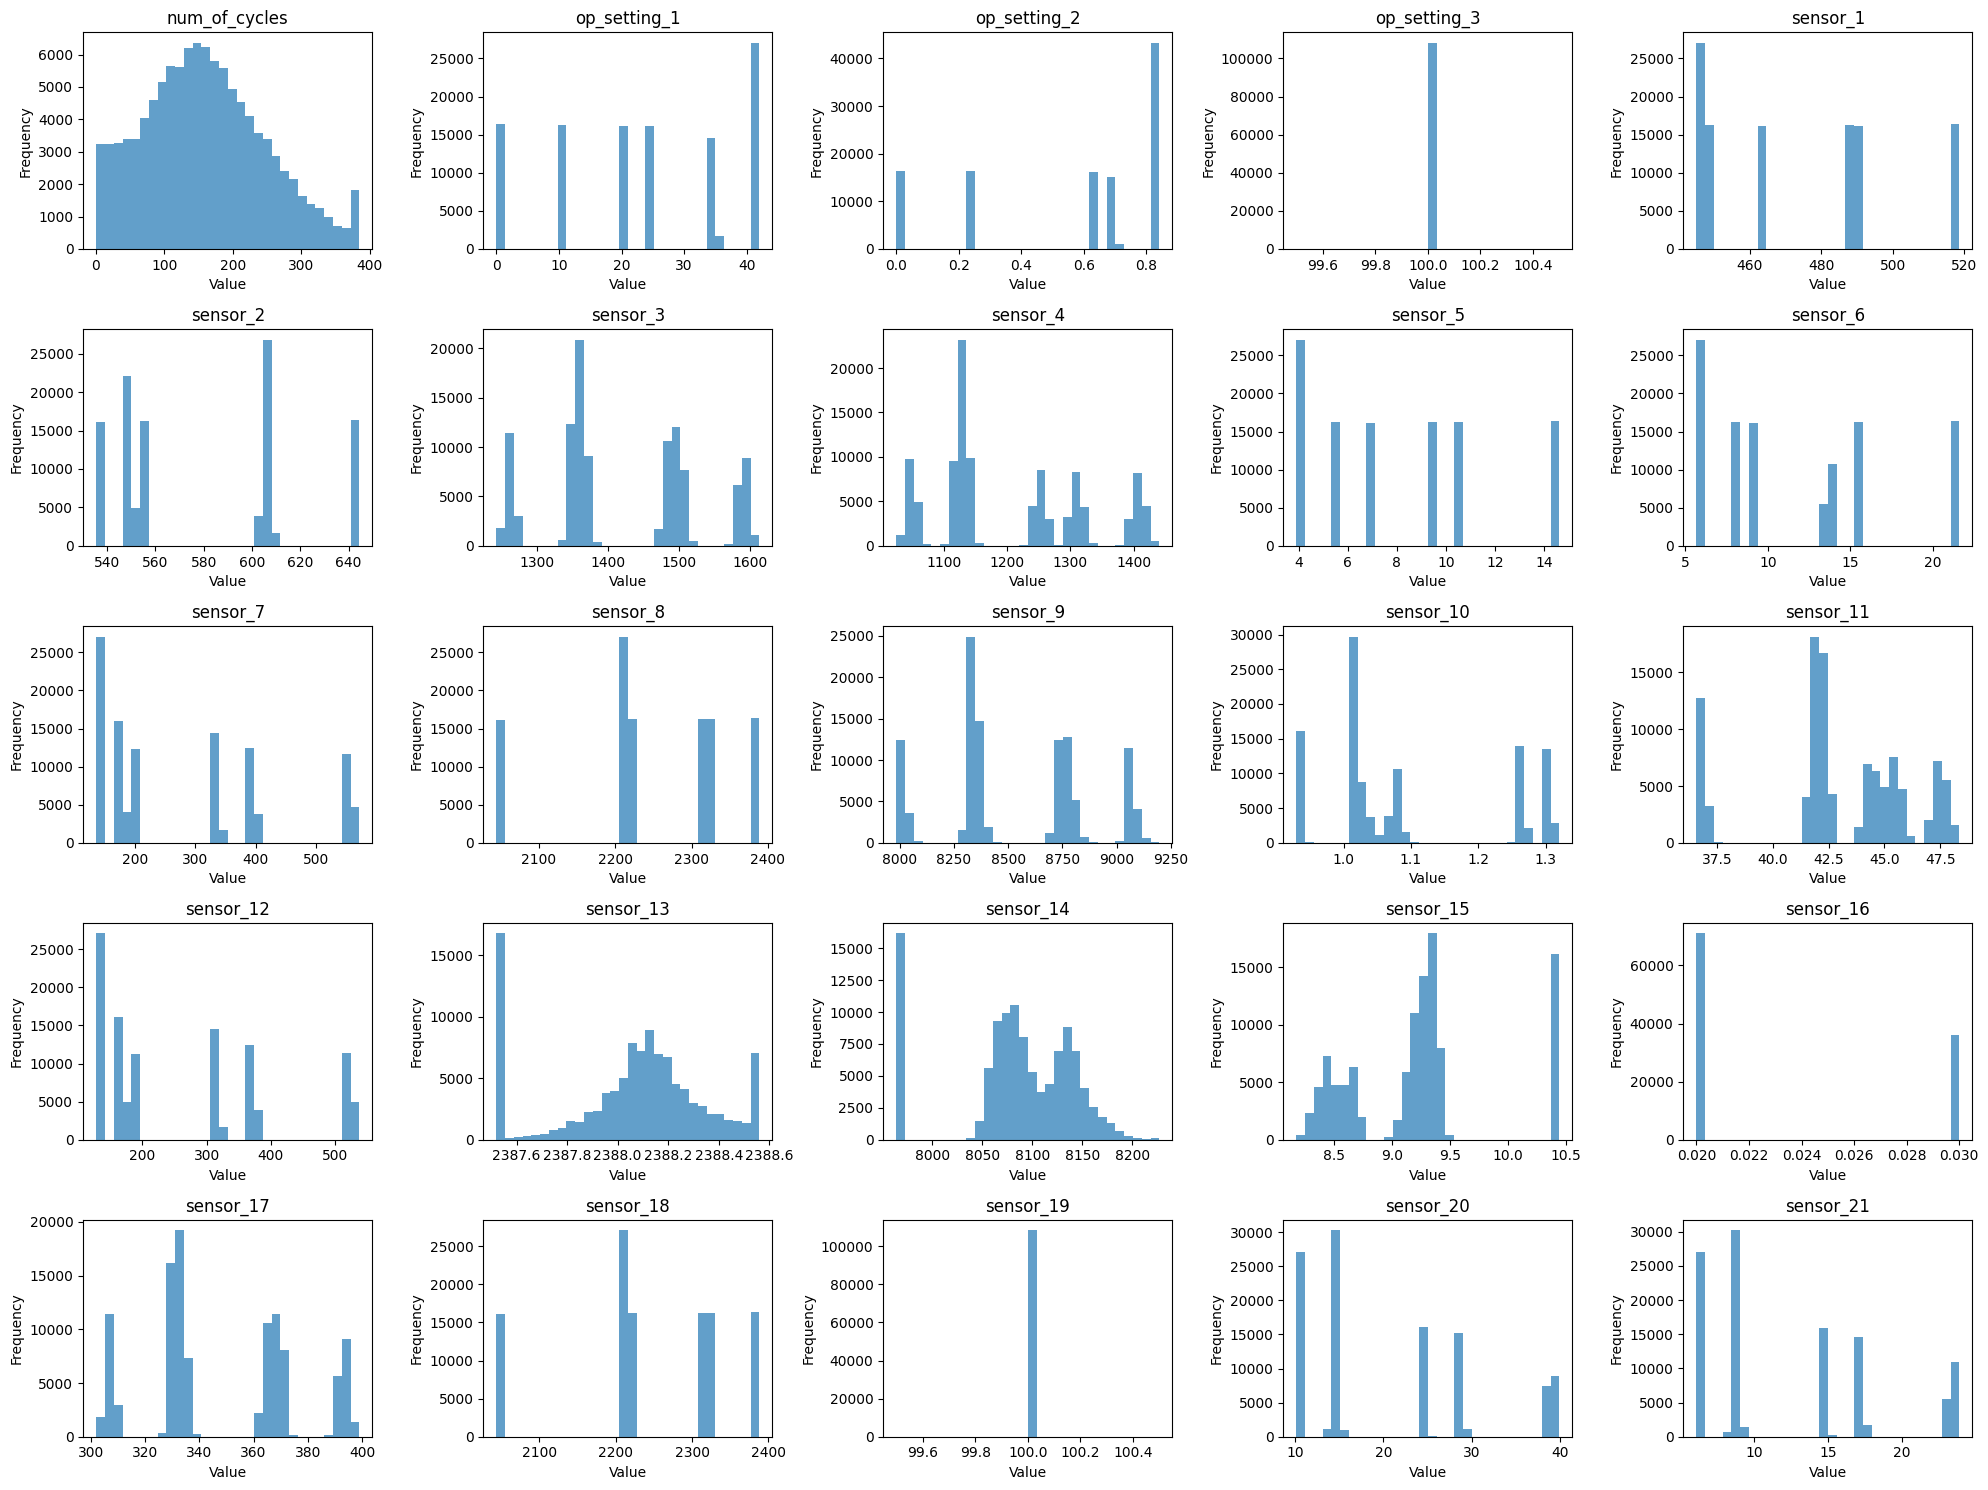

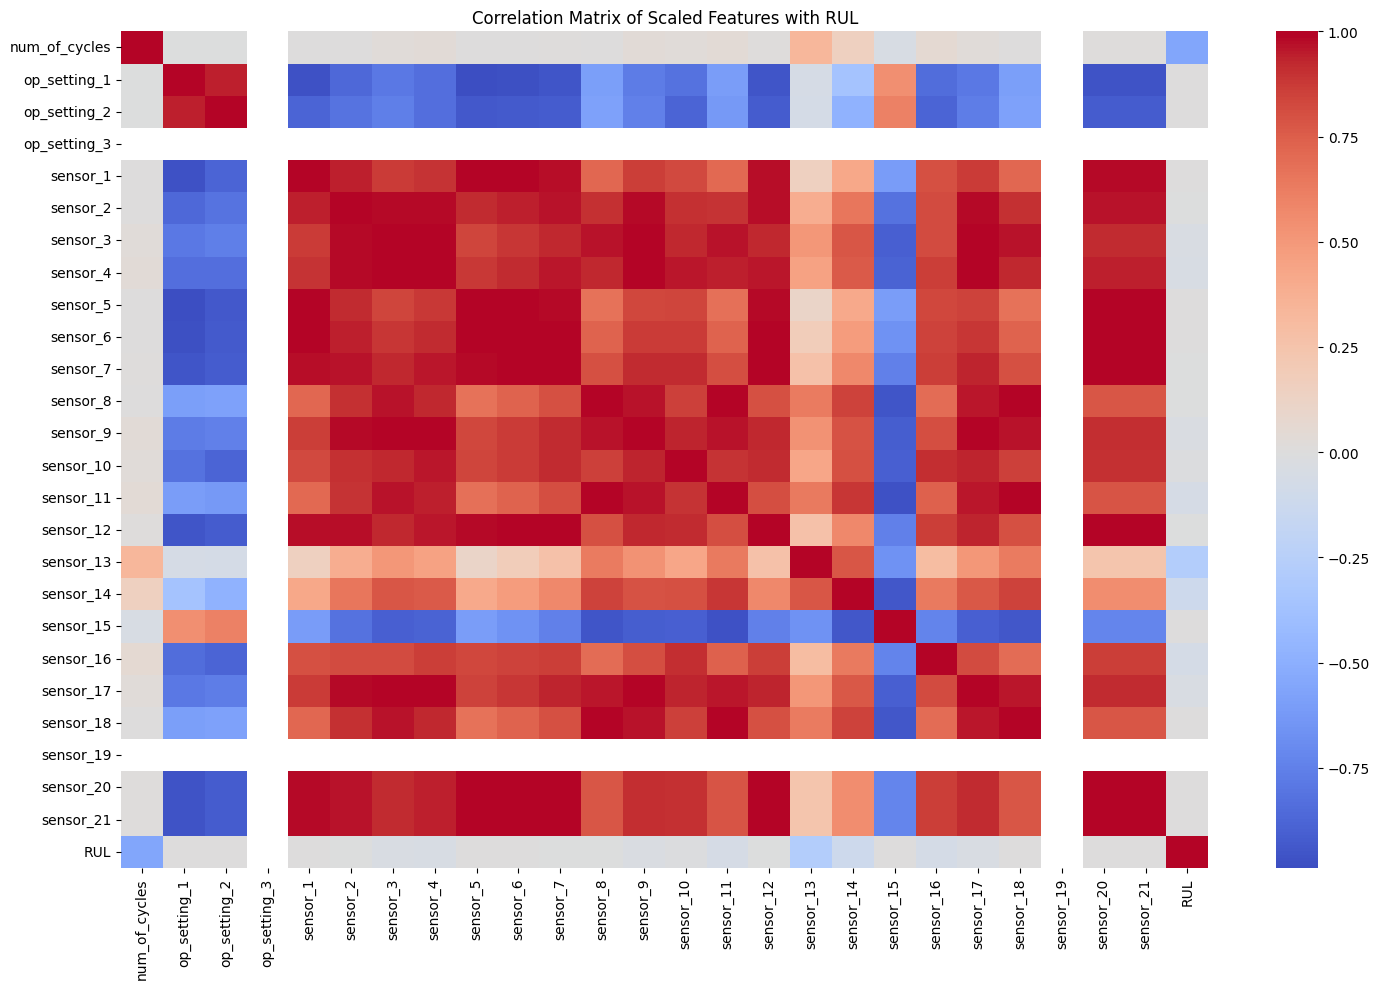

Visualization completed!


In [132]:
print("\n" + "="*50)
print("FINAL DATA VISUALIZATION")
print("="*50)

# Use scaled features from classification dataset for visualization
X_scaled_vis = X_scaled_df.copy()  # This is from feature scaling step

# Visualize scaled features (first 25 only)
fig, axes = plt.subplots(5, 5, figsize=(20, 15))
axes = axes.ravel()

for i in range(25):
    if i < len(X_scaled_vis.columns):
        axes[i].hist(X_scaled_vis.iloc[:, i], bins=30, alpha=0.7)
        axes[i].set_title(X_scaled_vis.columns[i])
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()

# Correlation heatmap with RUL
if y_rul is not None:
    plt.figure(figsize=(15, 10))
    temp_df = X_scaled_vis.copy()
    temp_df['RUL'] = y_rul
    correlation_matrix = temp_df.corr()
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Scaled Features with RUL')
    plt.tight_layout()
    plt.show()

# Correlation heatmap with class (using encoded version)
if 'class_encoded' in df_balanced.columns:
    plt.figure(figsize=(15, 10))
    temp_df = X_scaled_vis.copy()
    temp_df['class_encoded'] = df_balanced['class_encoded'].values
    correlation_matrix = temp_df.corr()
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Scaled Features with Class (Encoded)')
    plt.tight_layout()
    plt.show()

print("Visualization completed!")
print("="*50)